**Justin Hovious**

**Wave_Energy_Farm_EDA**

# Exploratory Data Analysis (EDA)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data = pd.read_csv("/content/drive/MyDrive/Machine Learning/CSCI 460/Large-scale Wave Energy Farm/WEC_Perth_49.csv")
df = pd.DataFrame(data)

In [5]:
df.head()

,X1,Y1,X2,Y2,X3,Y3,X4,Y4,X5,Y5,...,Power42,Power43,Power44,Power45,Power46,Power47,Power48,Power49,qW,Total_Power
0,600.0,0.0,546.16,37.50,489.79,74.88,432.47,112.05,650.0,0.0,...,88867.92,98844.30,101283.59,98934.63,101624.58,100915.03,99625.68,96704.34,0.87,4102461.43
1,593.0,12.0,546.16,37.50,489.79,74.88,432.47,112.05,644.0,8.0,...,88896.55,98759.79,101346.07,98873.59,101629.01,100934.53,99606.13,96718.39,0.87,4103361.41
2,593.0,12.0,546.16,37.50,489.79,74.88,432.47,112.05,644.0,8.0,...,88919.83,98746.68,101346.15,98875.57,101618.32,100941.00,99611.35,96719.14,0.87,4103680.44
3,593.0,12.0,546.16,37.50,489.79,74.88,432.47,112.05,644.0,8.0,...,88855.14,98760.96,101338.59,98971.58,101632.28,100943.59,99589.25,96735.04,0.87,4105661.06
4,200.0,0.0,146.17,37.53,89.76,74.93,32.40,112.18,400.0,0.0,...,88005.30,98630.24,100432.73,98803.01,101064.48,100948.38,99028.87,96286.71,0.79,3752648.77


In [6]:
df.tail()

,X1,Y1,X2,Y2,X3,Y3,X4,Y4,X5,Y5,...,Power42,Power43,Power44,Power45,Power46,Power47,Power48,Power49,qW,Total_Power
36038,100.0,250.0,250.0,250.0,300.0,200.0,400.0,100.0,900.0,150.0,...,100382.68,90042.10,99539.28,100219.37,70180.74,98693.05,100739.06,100530.96,0.86,4048188.53
36039,250.0,200.0,500.0,150.0,350.0,200.0,700.0,500.0,50.0,250.0,...,97576.89,89874.39,99413.89,83966.40,74140.17,66977.16,99768.78,92788.85,0.85,4033017.16
36040,200.0,100.0,400.0,100.0,350.0,500.0,750.0,200.0,700.0,250.0,...,101072.75,98181.96,77322.16,77632.27,102878.91,83002.93,91852.61,98283.28,0.86,4048053.62
36041,500.0,250.0,350.0,350.0,1000.0,250.0,550.0,150.0,800.0,0.0,...,99078.22,101120.28,73597.78,102042.99,58438.65,98804.39,66383.44,97423.85,0.86,4062515.64
36042,100.0,400.0,400.0,700.0,400.0,200.0,800.0,50.0,350.0,250.0,...,101467.79,97602.18,63219.97,90117.87,73152.07,99875.52,101412.65,76111.53,0.86,4057544.99


In [7]:
df.shape

(36043, 149)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36043 entries, 0 to 36042
Columns: 149 entries, X1 to Total_Power
dtypes: float64(149)
memory usage: 41.0 MB


In [9]:
# Checking for duplication
df.nunique()

,0
X1,98
Y1,102
X2,362
Y2,276
X3,398
...,...
Power47,9810
Power48,9936
Power49,9966
qW,17


In [10]:
# Indicates there are no missing values
df.isnull().sum()

,0
X1,0
Y1,0
X2,0
Y2,0
X3,0
...,...
Power47,0
Power48,0
Power49,0
qW,0


In [25]:
# Collecting initial statistic data on the dataset
print(df.describe().T)

               count          mean            std         min         25%  \
X1           36043.0  3.665971e+02     307.911246        0.00       65.77   
Y1           36043.0  1.870955e+01      44.043295        0.00        0.00   
X2           36043.0  4.263140e+02     265.781316        0.00      200.00   
Y2           36043.0  5.108576e+01      90.151852        0.00        0.00   
X3           36043.0  4.772956e+02     270.322011        0.00      289.95   
...              ...           ...            ...         ...         ...   
Power47      36043.0  9.810628e+04    4263.508074    63028.26    97154.63   
Power48      36043.0  9.746266e+04    3134.420742    61717.31    96869.74   
Power49      36043.0  9.613492e+04    3889.098339    47257.43    96319.55   
qW           36043.0  8.338493e-01       0.026052        0.72        0.81   
Total_Power  36043.0  3.938246e+06  122617.149926  3388944.15  3847334.53   

                    50%          75%         max  
X1               250.00 

In [24]:
# Checking initial correlation of features
df.corr()

,X1,Y1,X2,Y2,X3,Y3,X4,Y4,X5,Y5,...,Power42,Power43,Power44,Power45,Power46,Power47,Power48,Power49,qW,Total_Power
X1,1.000000,-0.382451,0.716254,-0.072653,0.457218,0.209945,0.167889,0.501921,0.202898,0.180497,...,0.147965,0.257203,0.087895,0.186521,0.300784,0.344825,0.188152,-0.075939,0.456554,0.458563
Y1,-0.382451,1.000000,-0.285771,0.260923,-0.138123,0.187707,0.124454,-0.213032,0.042977,0.107165,...,-0.032519,-0.127402,0.004177,-0.152655,-0.209164,-0.173642,-0.204873,-0.104366,-0.129129,-0.134121
X2,0.716254,-0.285771,1.000000,-0.245368,0.626875,-0.049490,0.385673,0.208370,0.111383,0.266250,...,-0.043140,0.115361,-0.054024,0.054080,0.069217,0.196161,0.127194,-0.058414,0.271043,0.273289
Y2,-0.072653,0.260923,-0.245368,1.000000,-0.170788,0.165352,0.066554,0.075869,0.151616,0.023583,...,0.059919,-0.080037,0.331083,0.010098,-0.138408,0.011761,-0.118694,-0.061212,0.083106,0.082262
X3,0.457218,-0.138123,0.626875,-0.170788,1.000000,-0.278195,0.503052,-0.090246,-0.051112,0.334379,...,-0.091241,-0.020662,-0.142705,-0.056927,-0.065776,-0.044414,0.033318,-0.011972,0.054713,0.055612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Power47,0.344825,-0.173642,0.196161,0.011761,-0.044414,0.271616,-0.260410,0.430854,0.096184,-0.084252,...,0.118601,0.347735,0.318731,0.236531,0.339094,1.000000,0.281746,-0.114634,0.408360,0.411912
Power48,0.188152,-0.204873,0.127194,-0.118694,0.033318,0.076719,-0.233066,0.210583,-0.062099,-0.148669,...,0.011397,0.214215,0.213452,0.123651,0.344850,0.281746,1.000000,-0.036249,0.179685,0.181082
Power49,-0.075939,-0.104366,-0.058414,-0.061212,-0.011972,-0.134862,-0.006768,-0.062498,-0.101209,0.056469,...,-0.196691,-0.169454,-0.059855,-0.019833,-0.099478,-0.114634,-0.036249,1.000000,-0.178464,-0.170845
qW,0.456554,-0.129129,0.271043,0.083106,0.054713,0.307045,-0.044803,0.441926,0.326664,-0.140143,...,0.300193,0.334010,0.309008,0.320354,0.335713,0.408360,0.179685,-0.178464,1.000000,0.993276


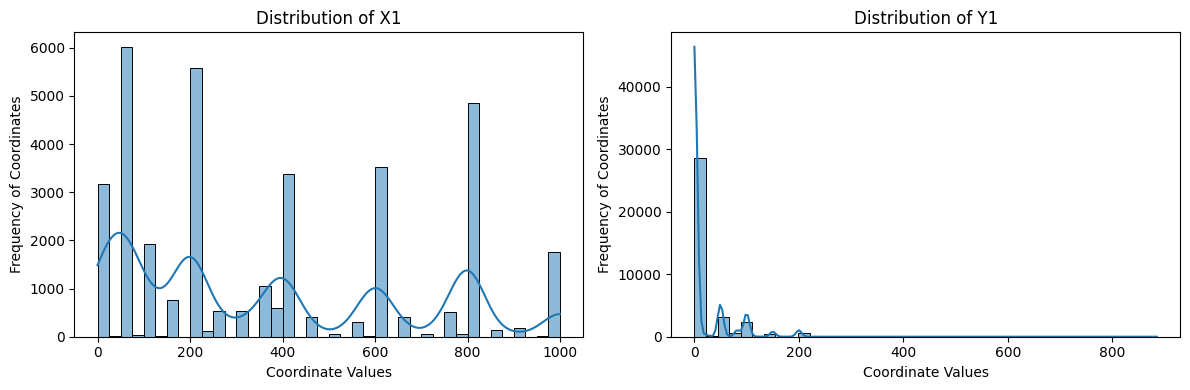

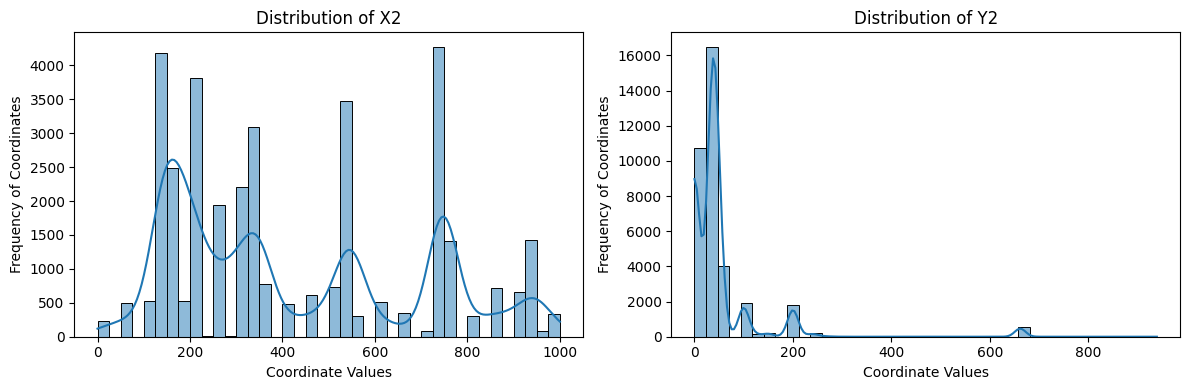

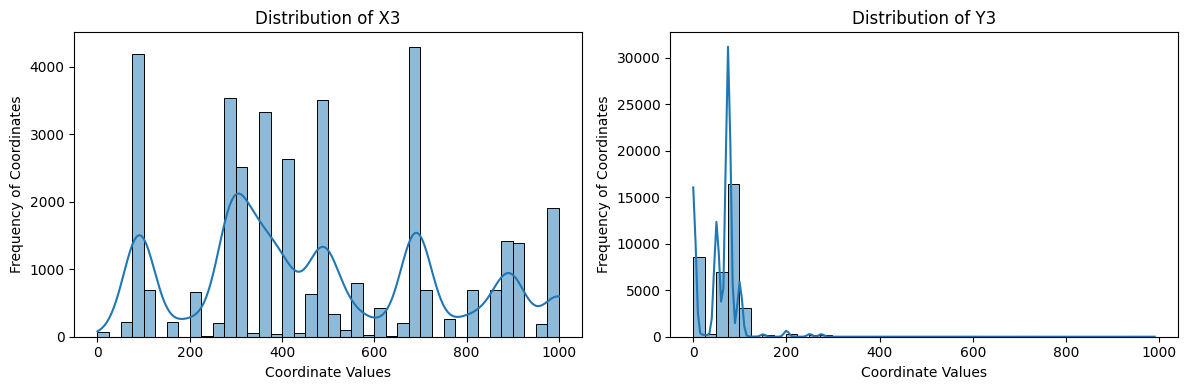

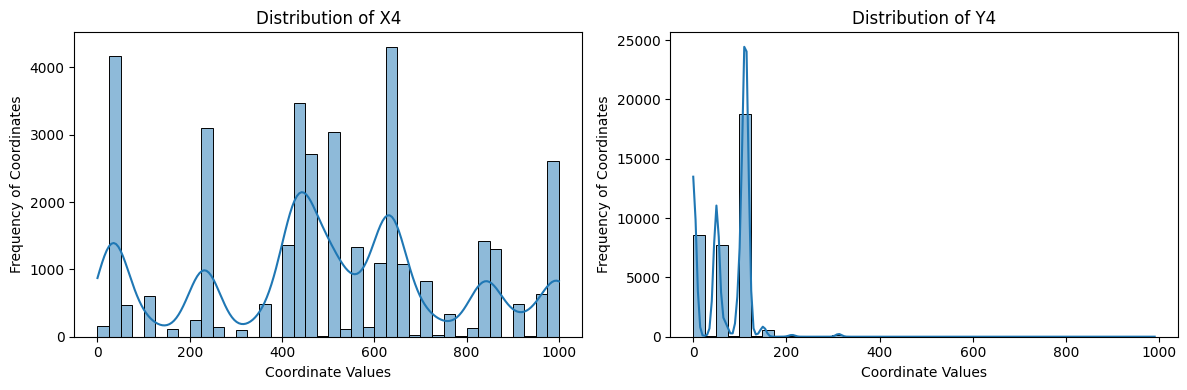

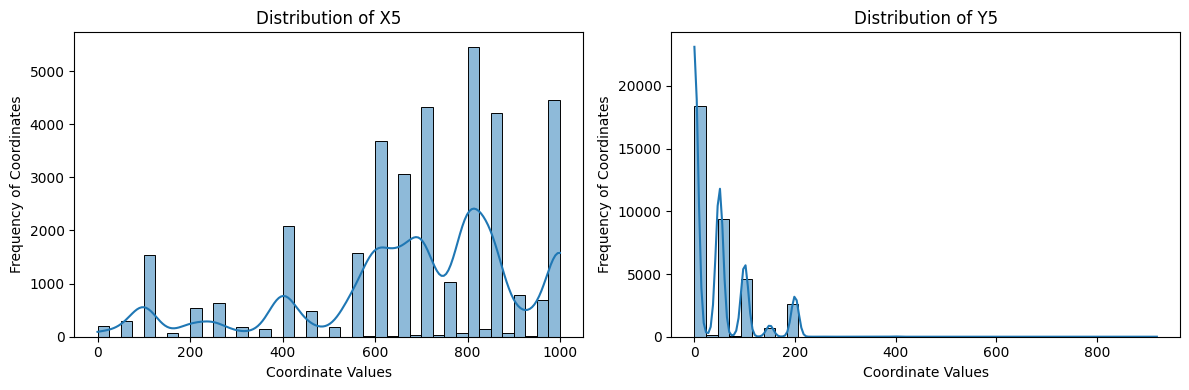

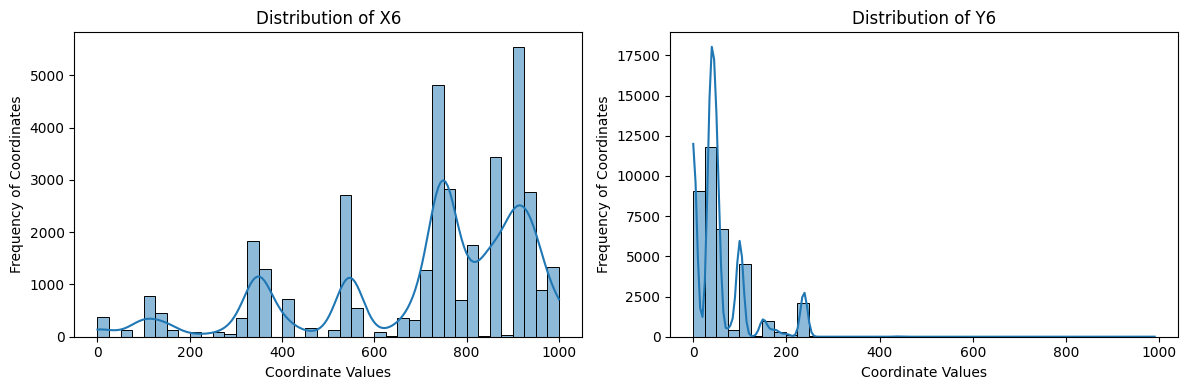

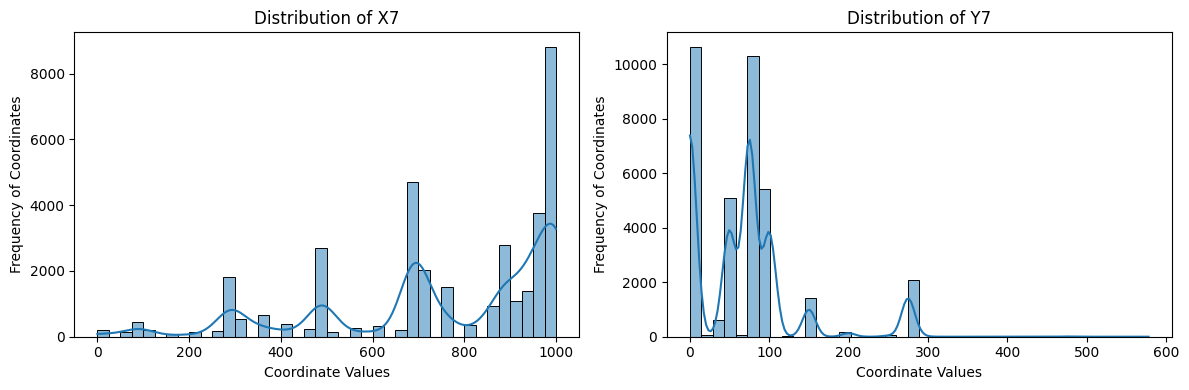

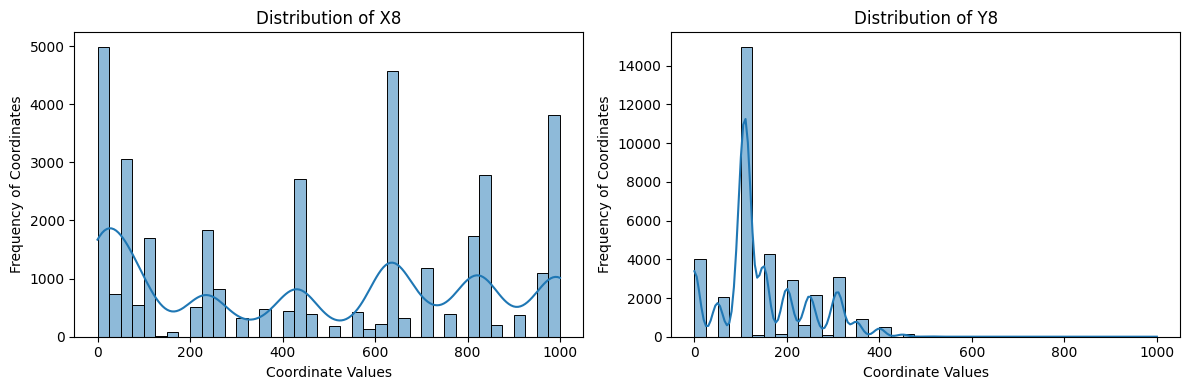

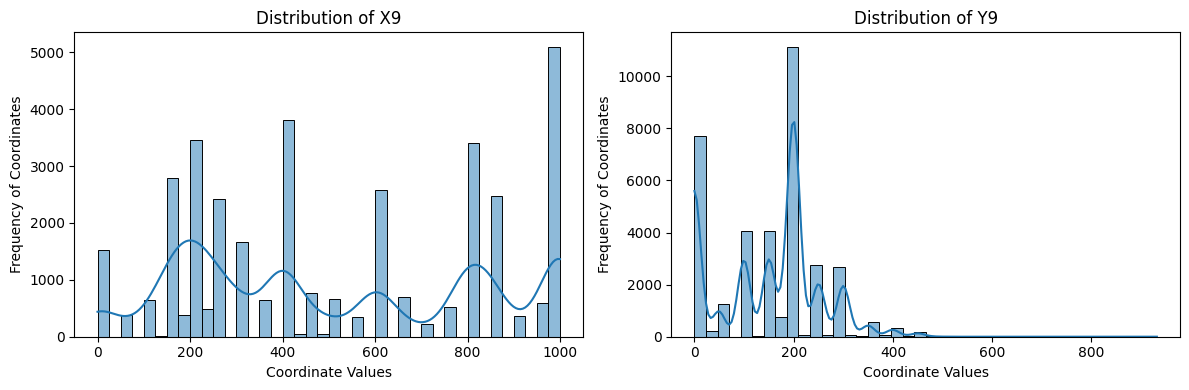

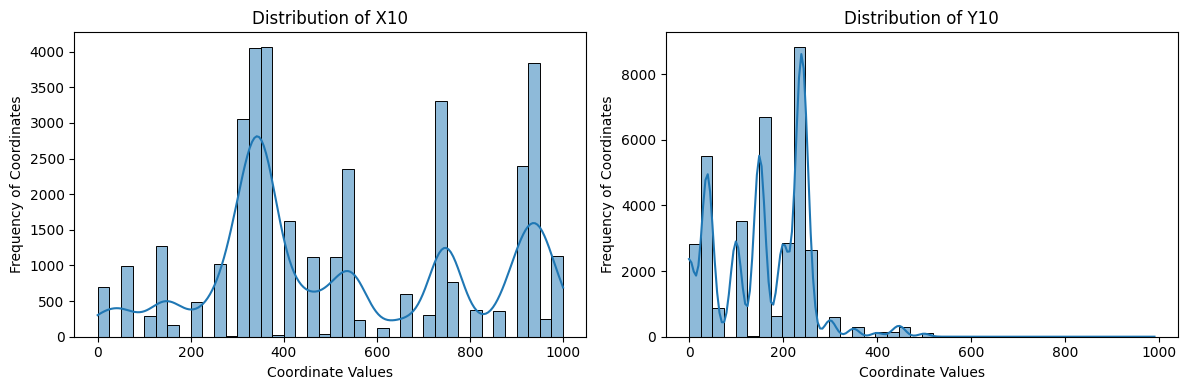

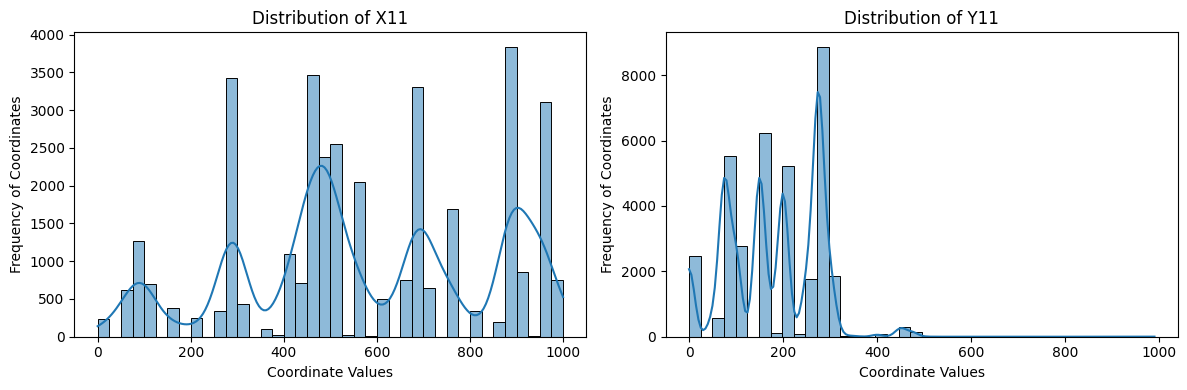

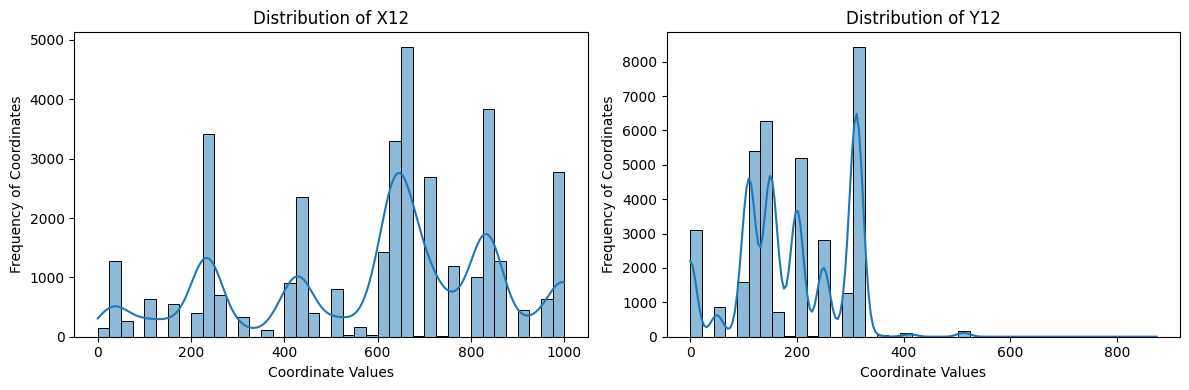

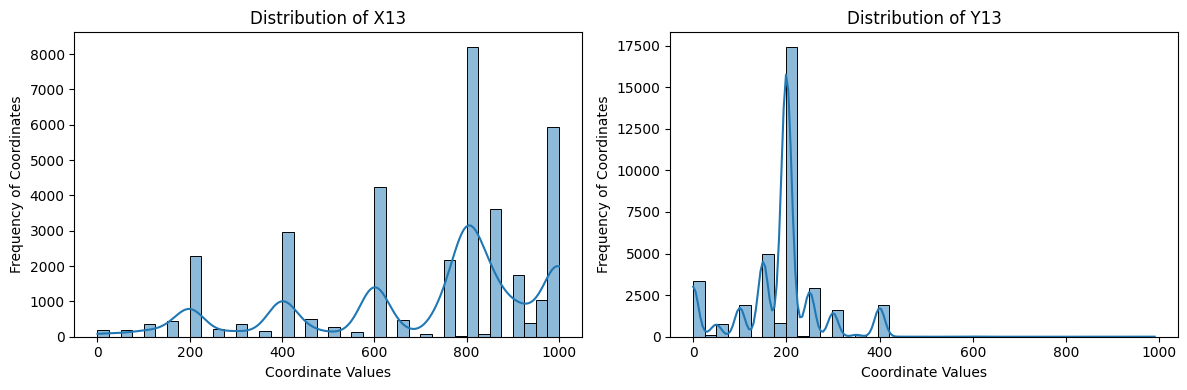

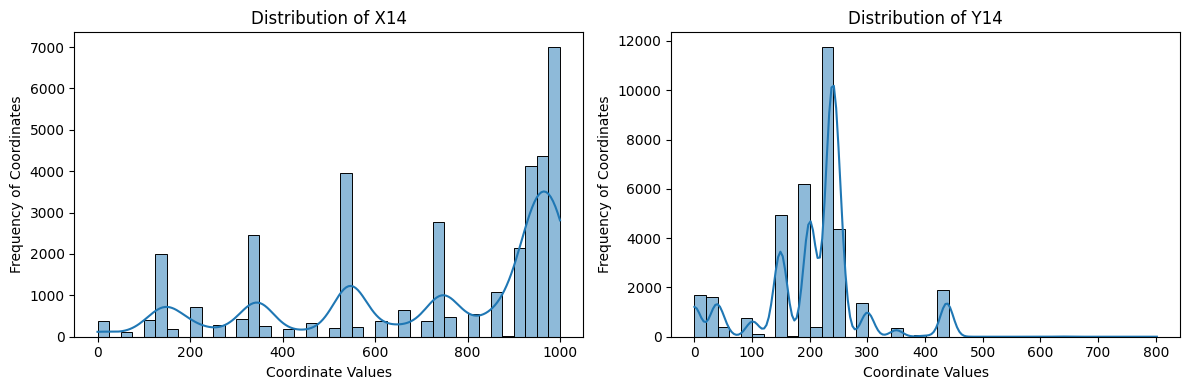

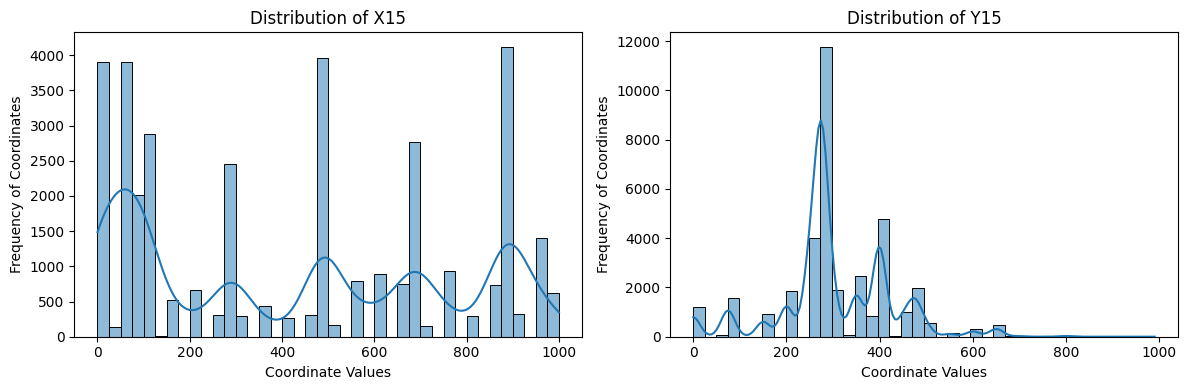

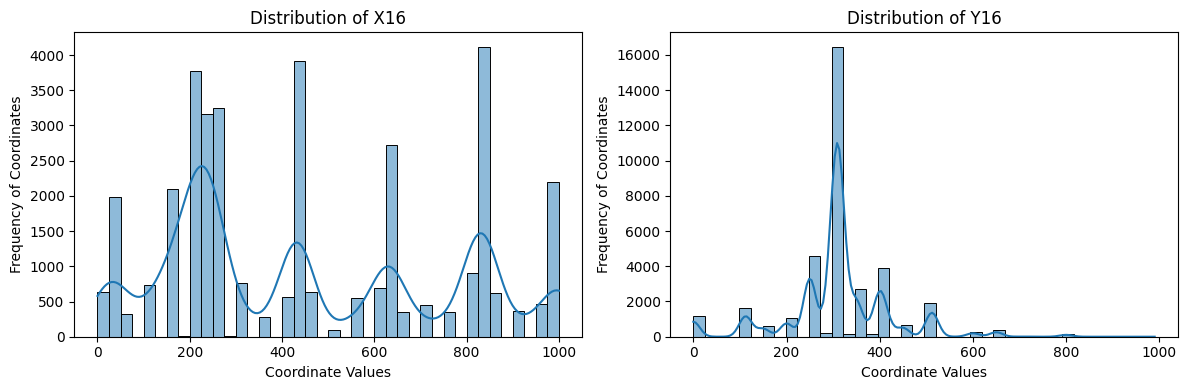

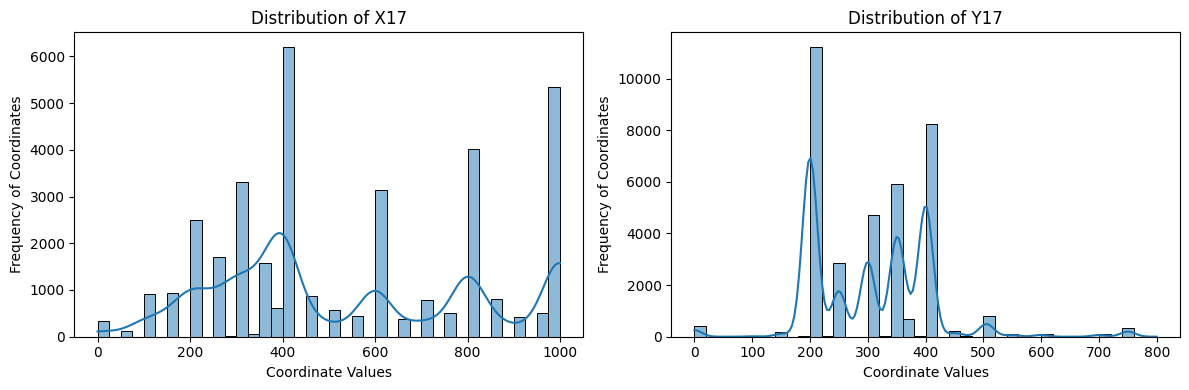

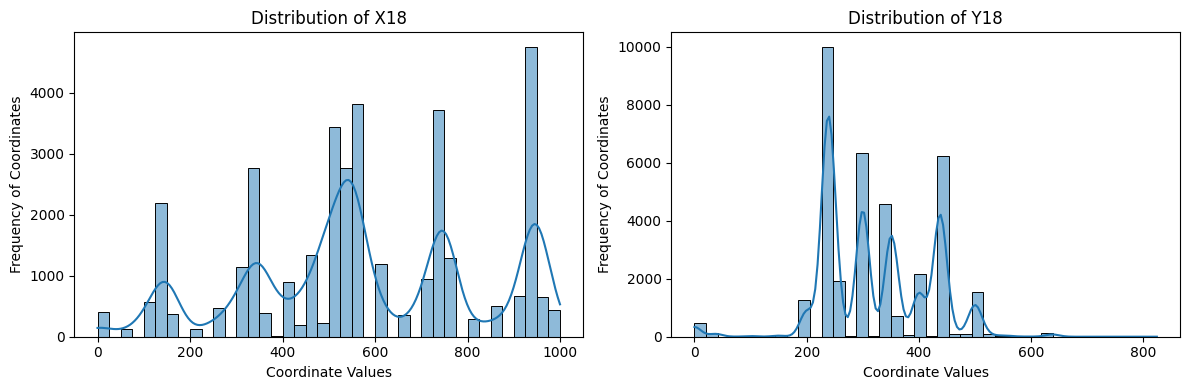

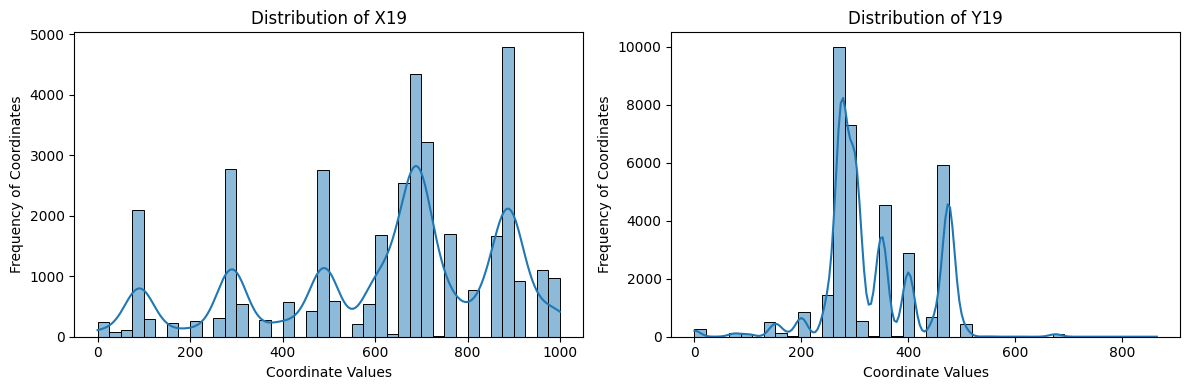

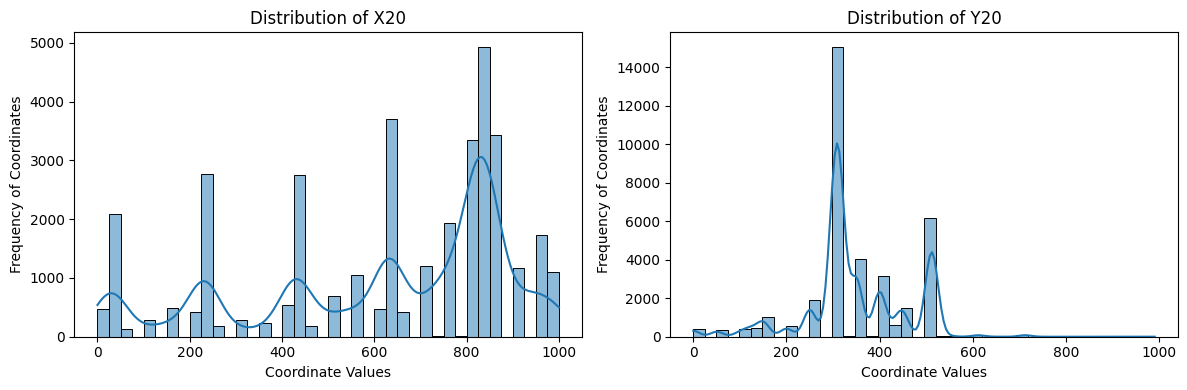

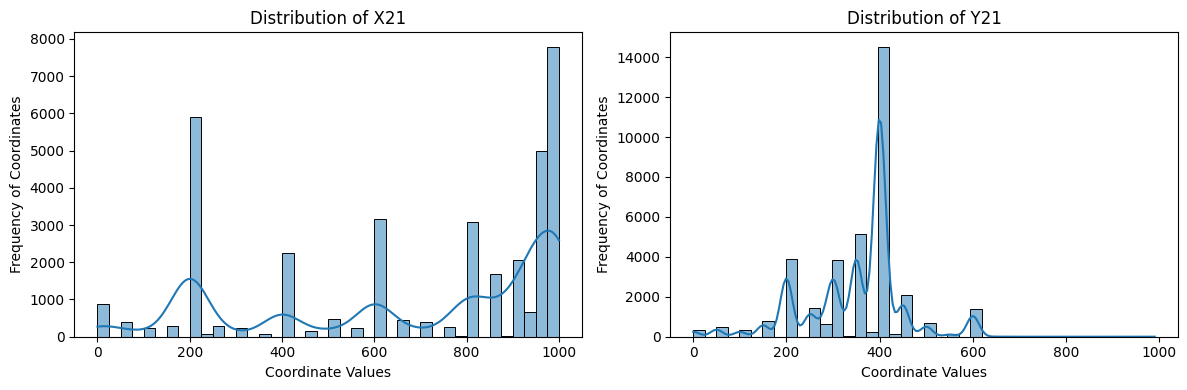

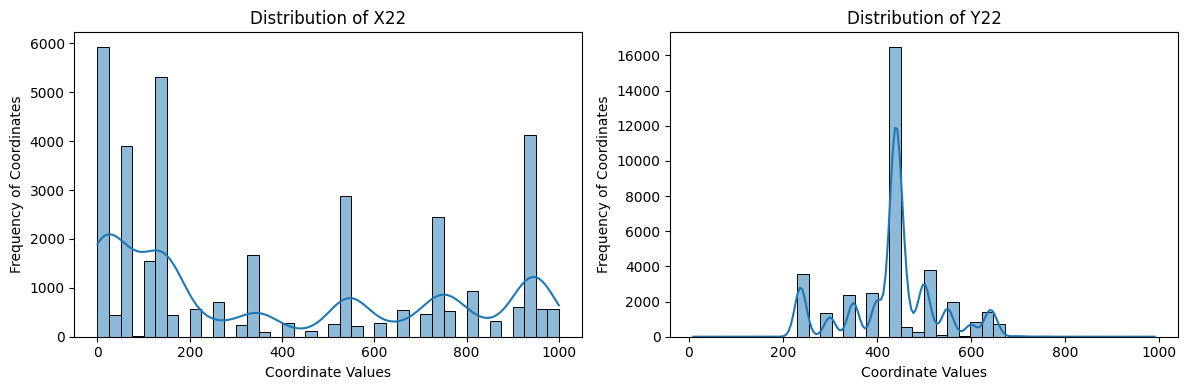

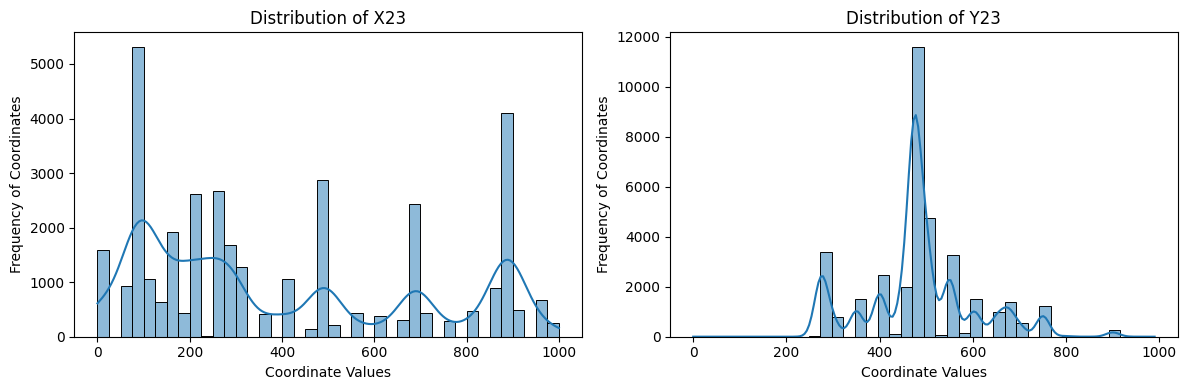

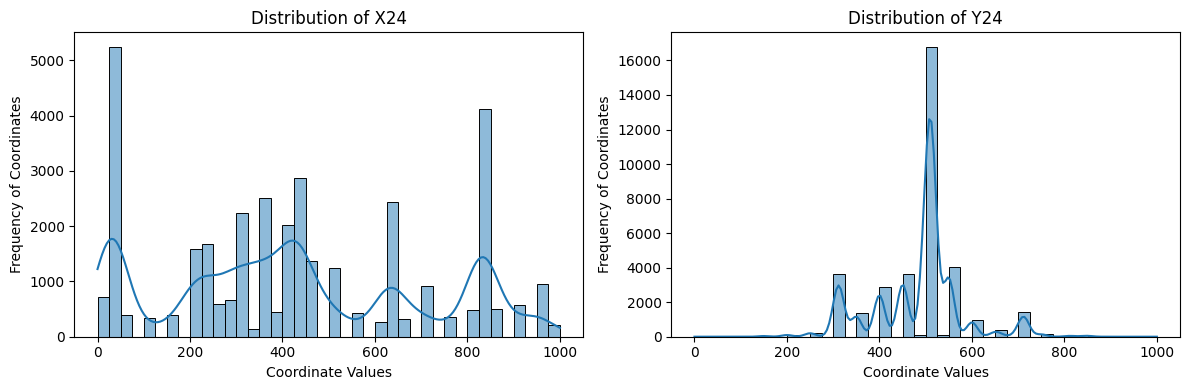

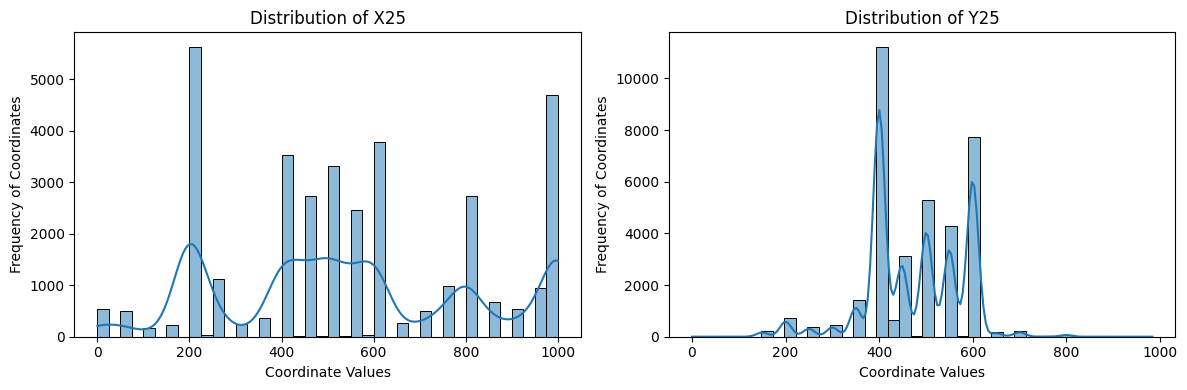

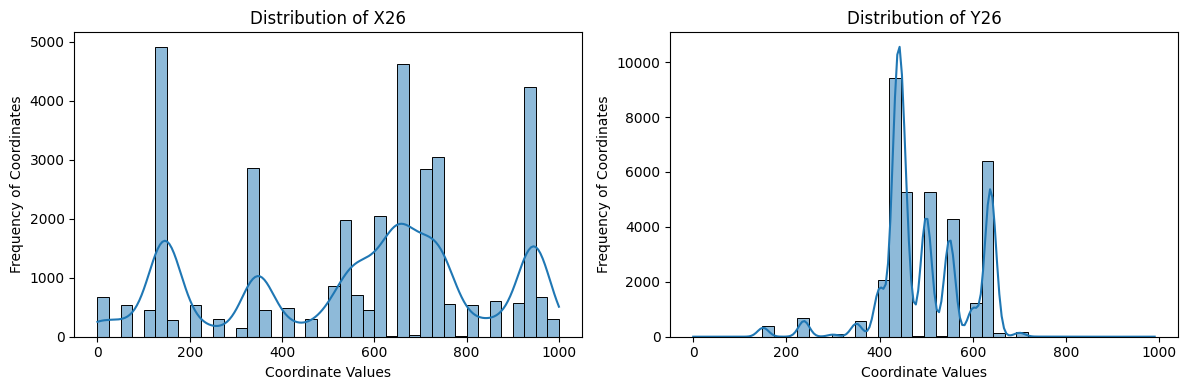

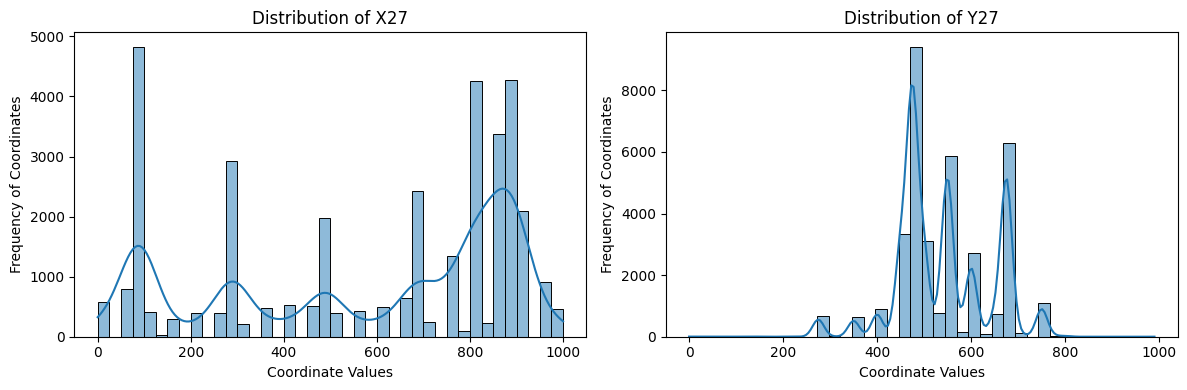

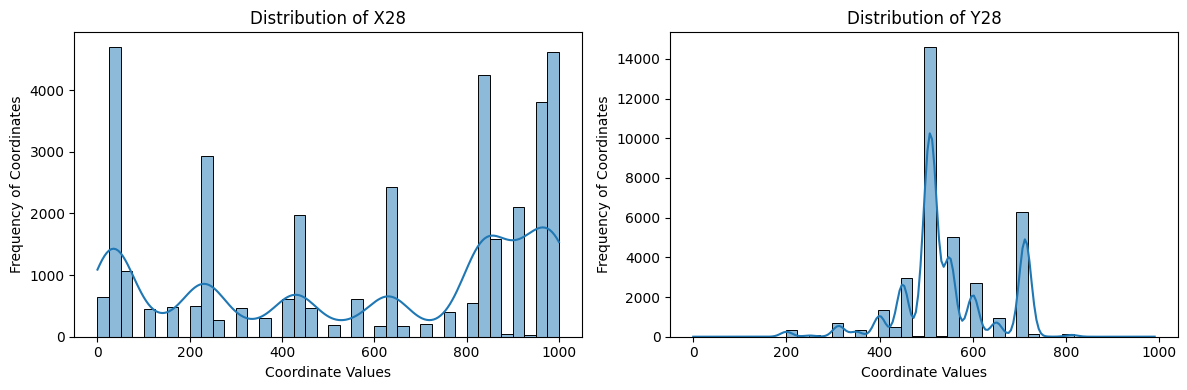

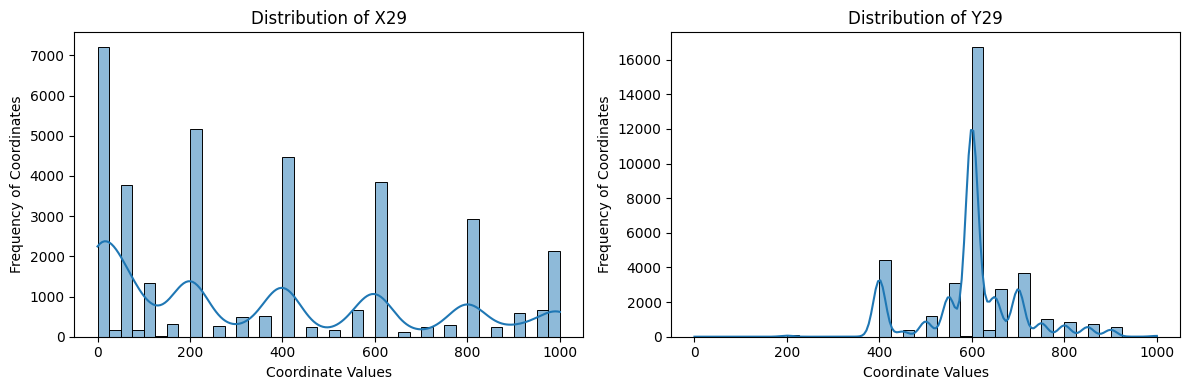

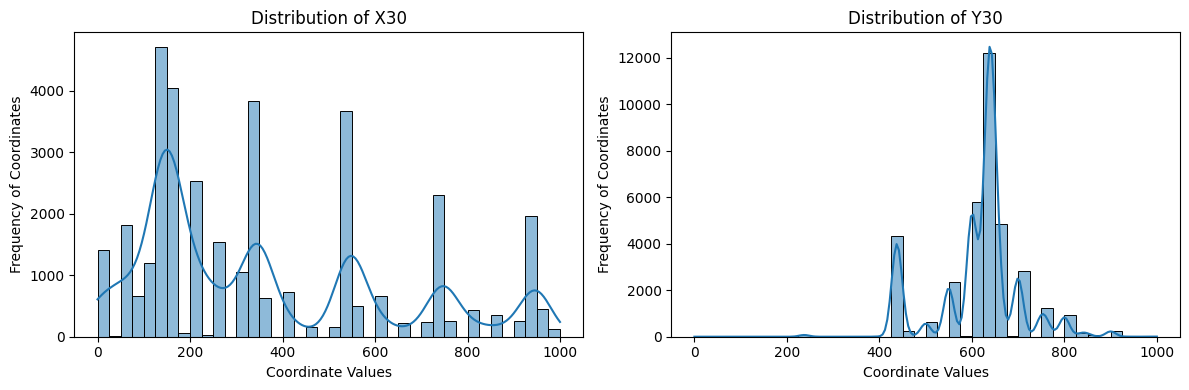

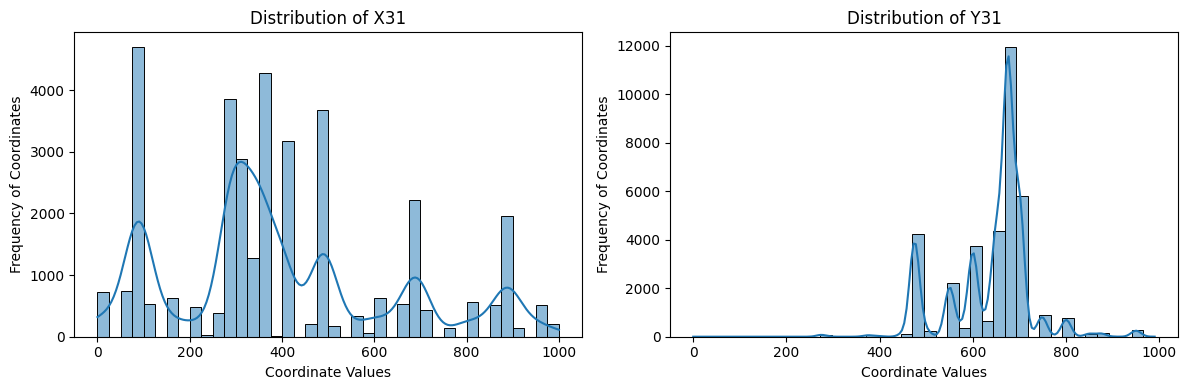

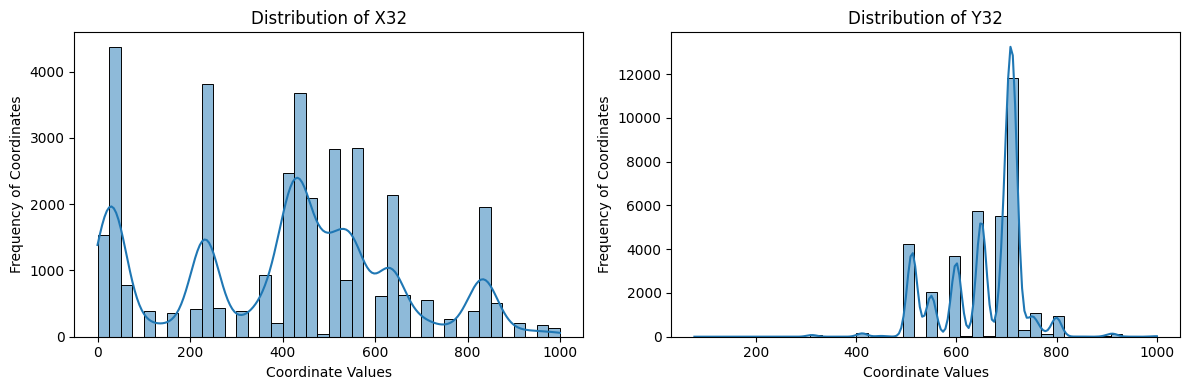

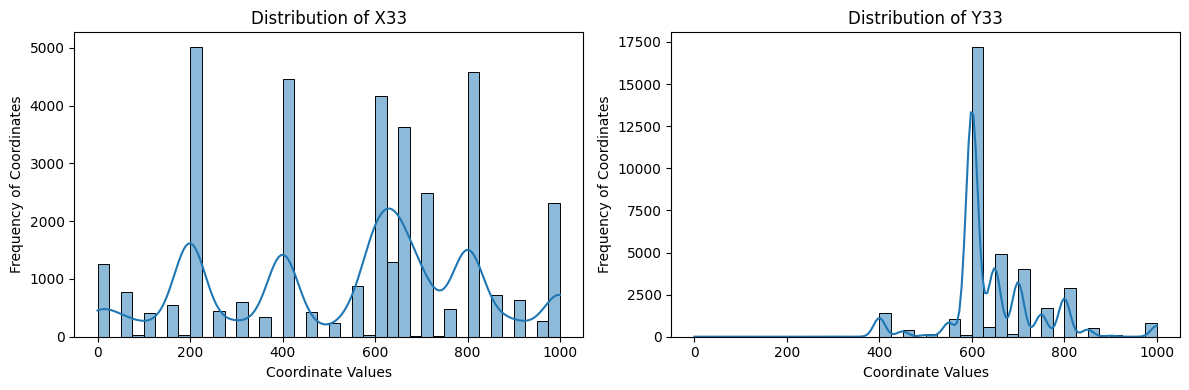

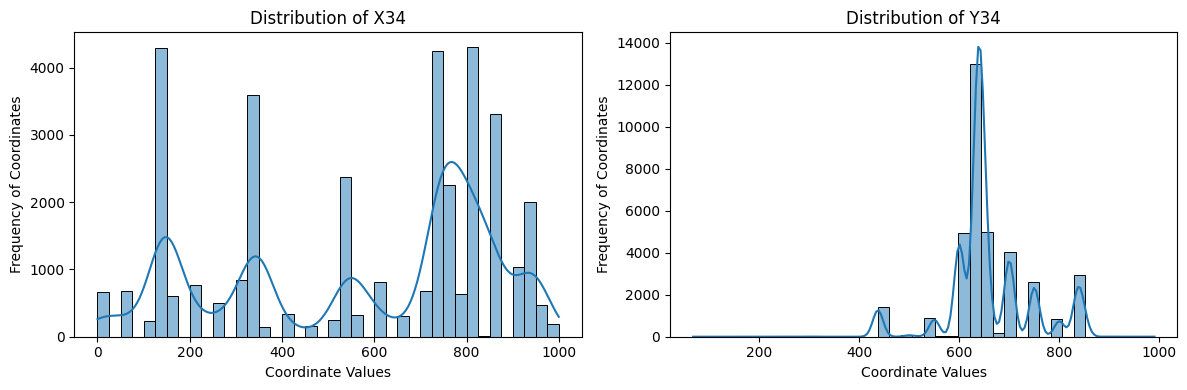

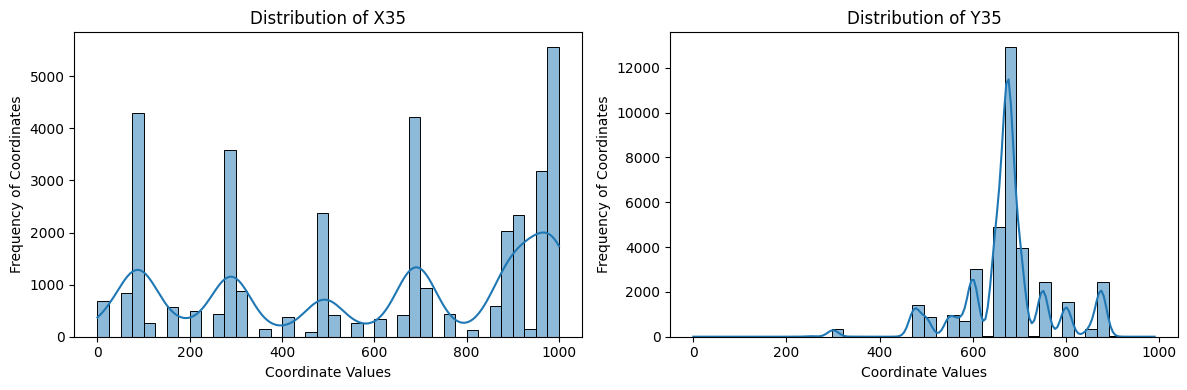

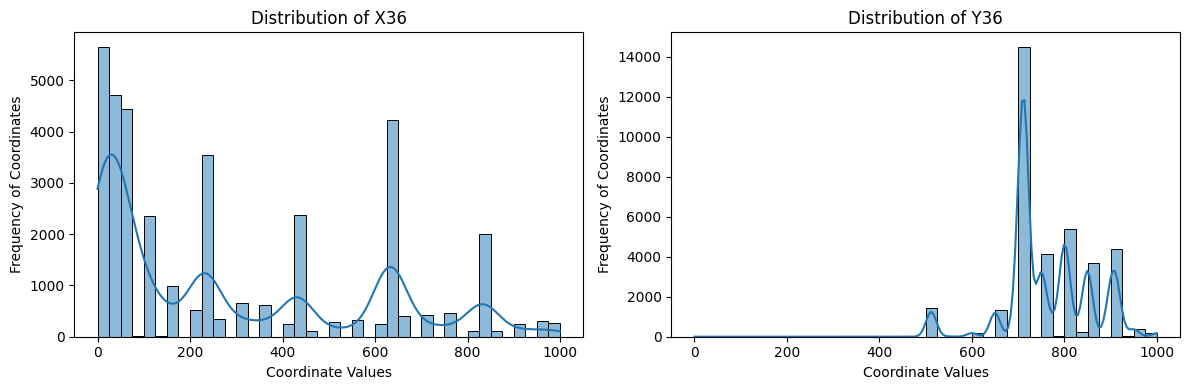

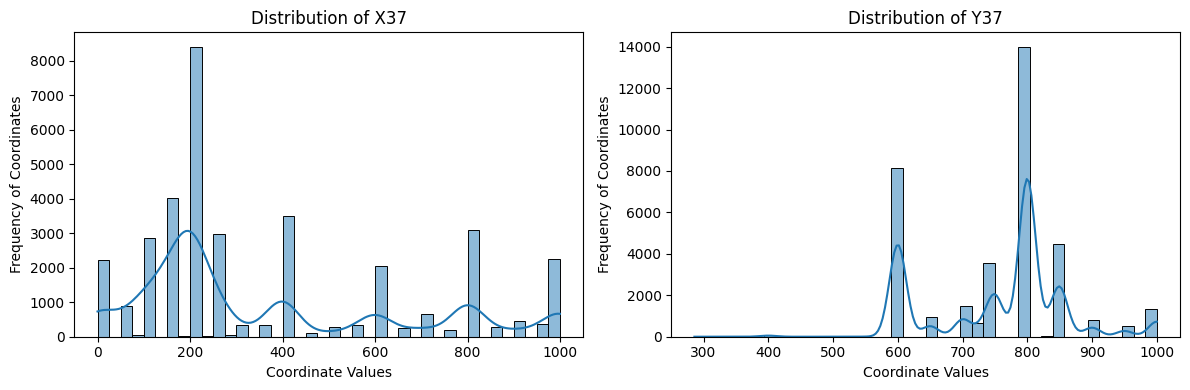

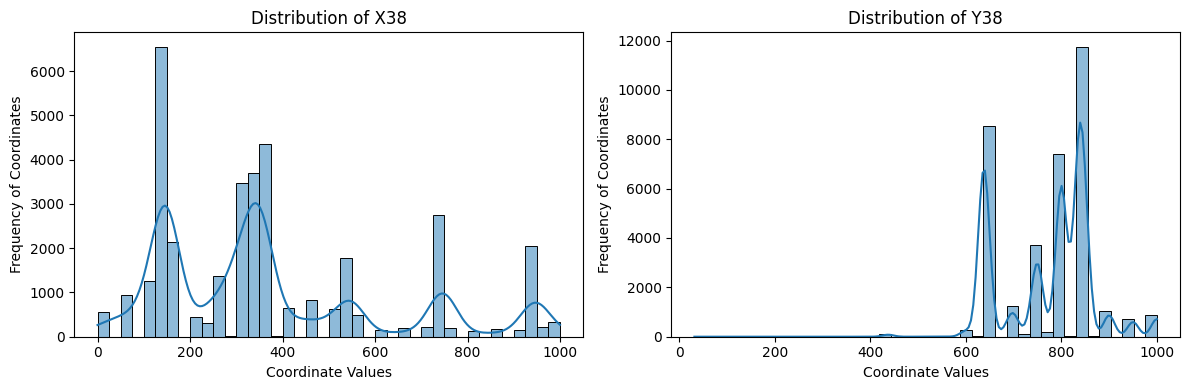

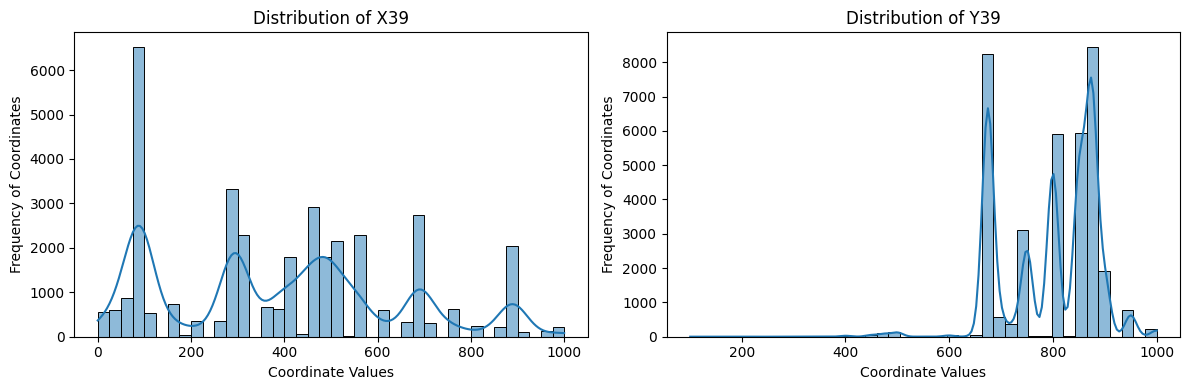

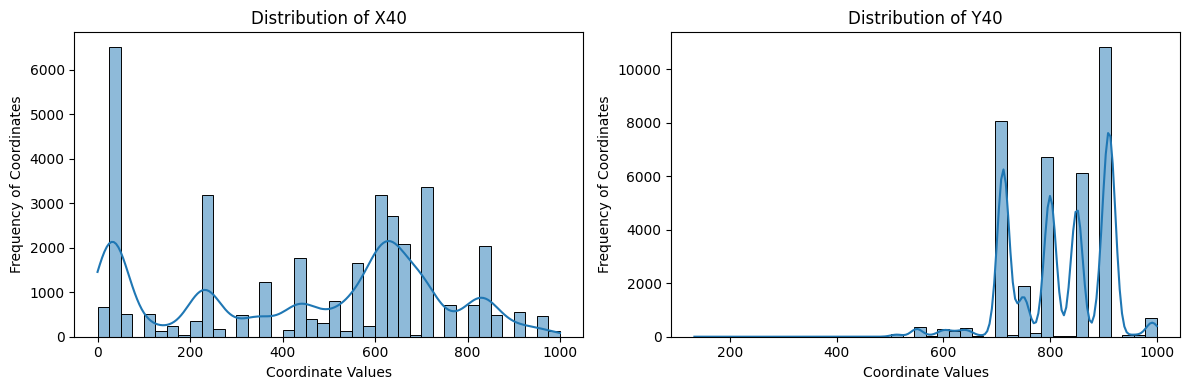

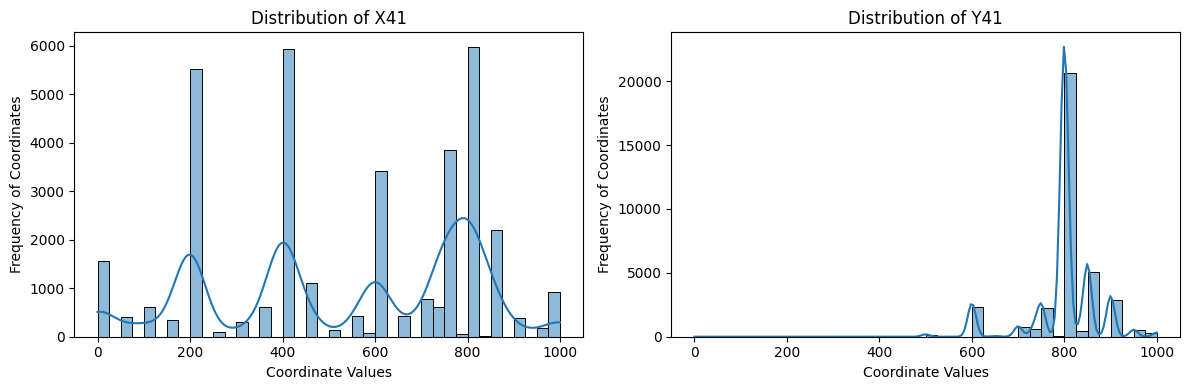

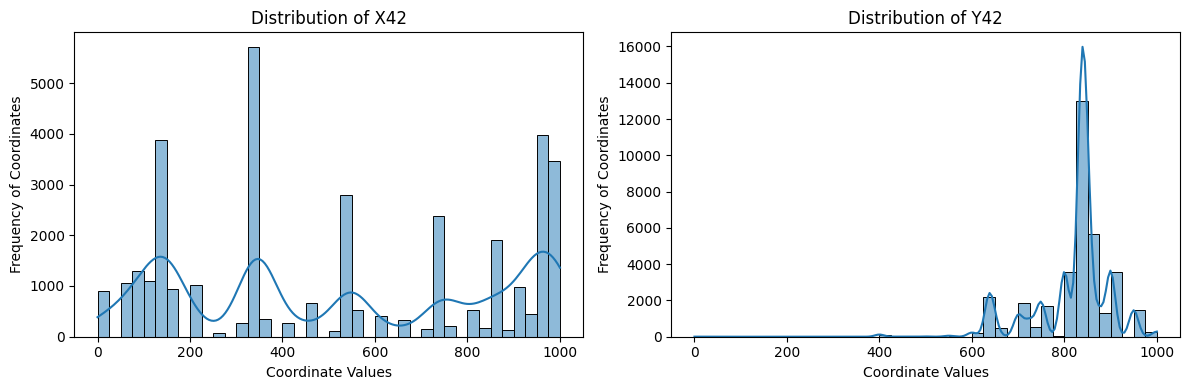

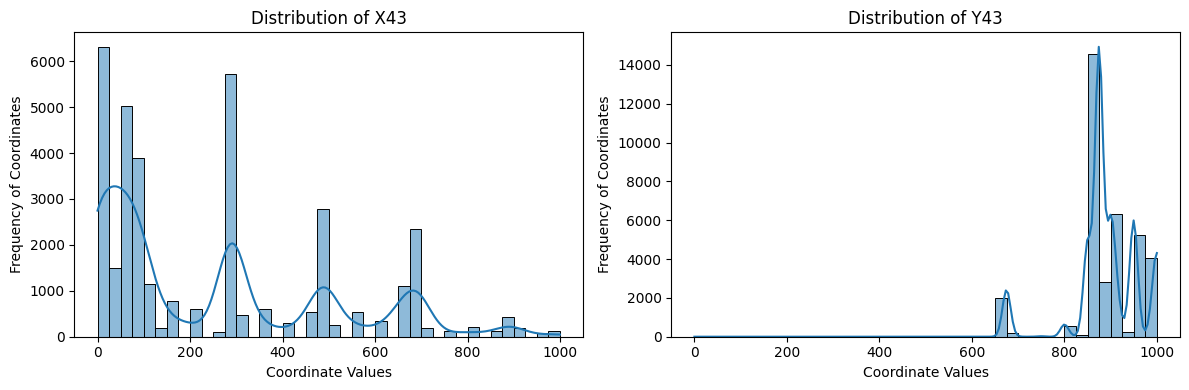

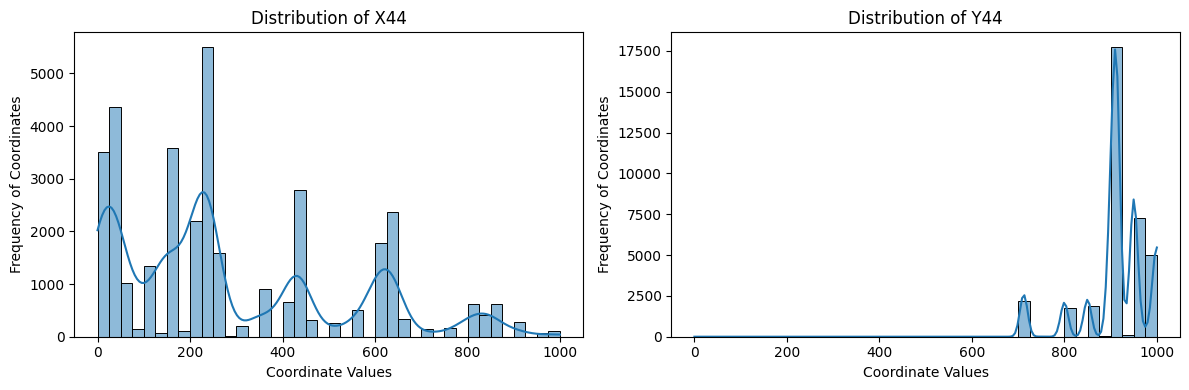

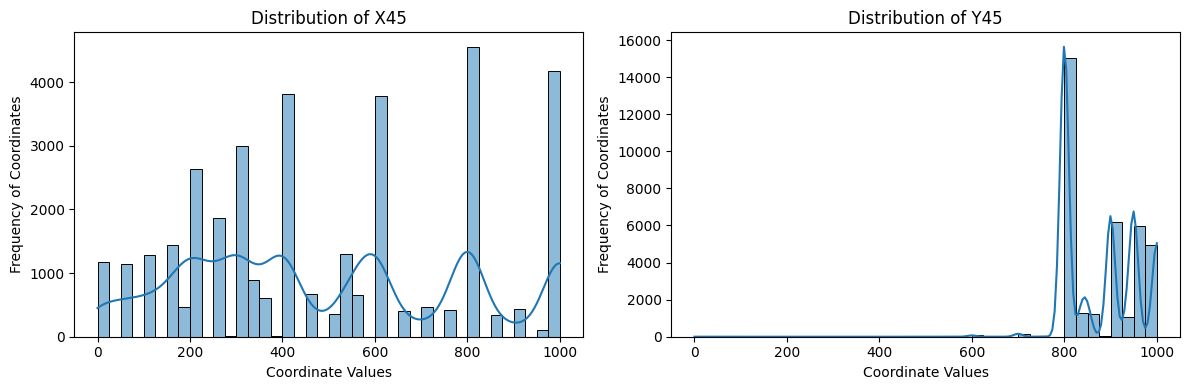

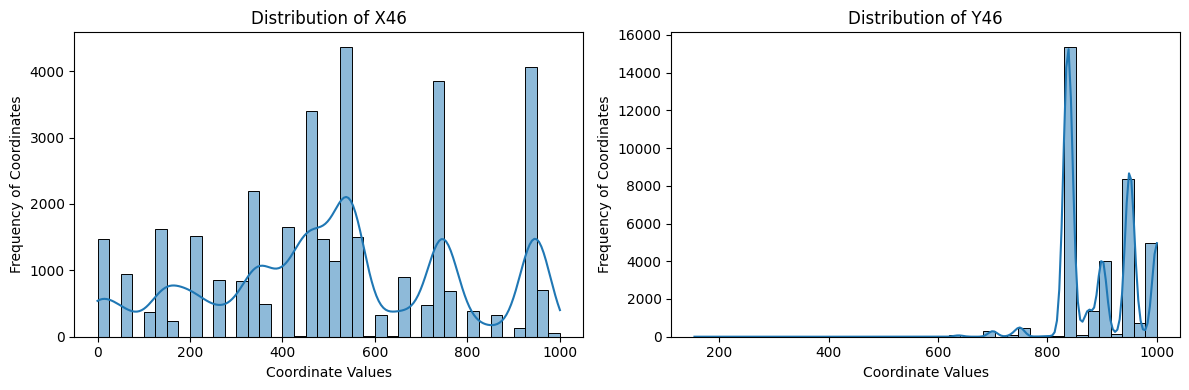

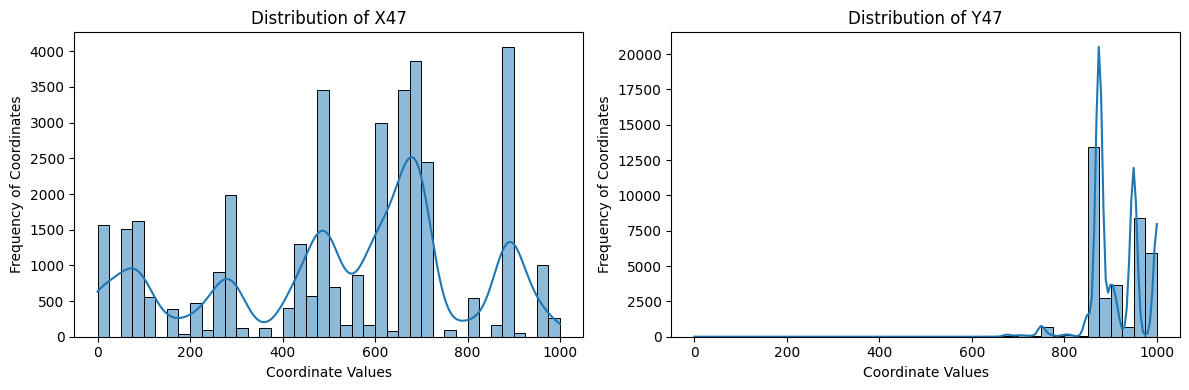

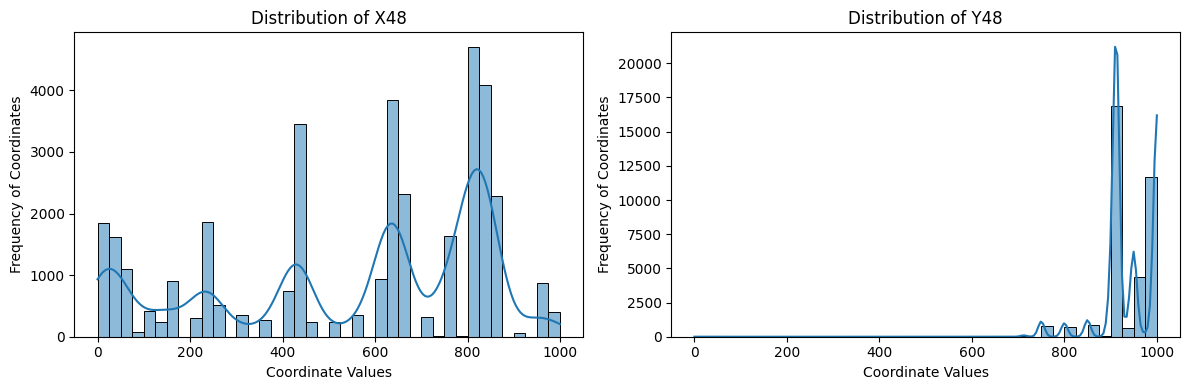

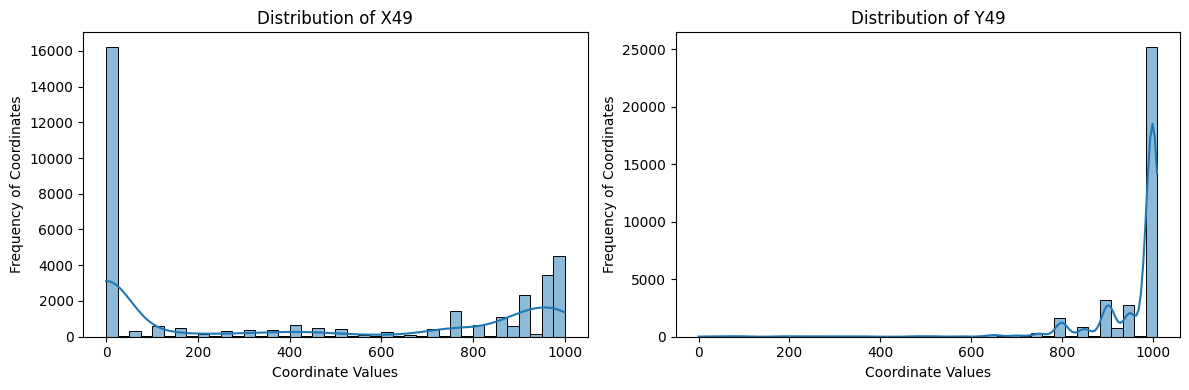

In [17]:
# Creating histograms for frequency of X,Y coordinates.
# Trying to identify any patterns or standard distribution between coordinates.
for i in range(1, 50):
    x_col = f"X{i}"
    y_col = f"Y{i}"

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # X distribution
    sns.histplot(df[x_col], kde=True, bins=40, ax=axes[0])
    axes[0].set_title(f"Distribution of {x_col}")
    axes[0].set_xlabel("Coordinate Values")
    axes[0].set_ylabel("Frequency of Coordinates")

    # Y distribution
    sns.histplot(df[y_col], kde=True, bins=40, ax=axes[1])
    axes[1].set_title(f"Distribution of {y_col}")
    axes[1].set_xlabel("Coordinate Values")
    axes[1].set_ylabel("Frequency of Coordinates")

    plt.tight_layout()
    plt.show()





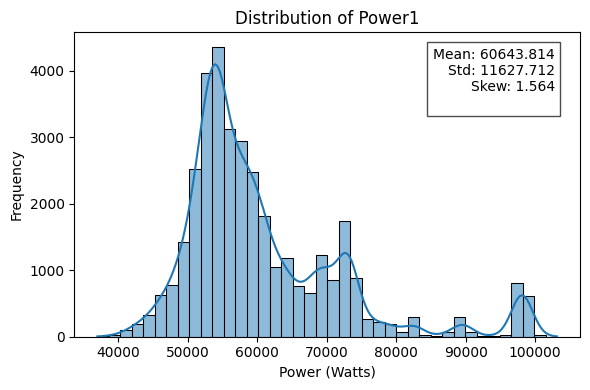

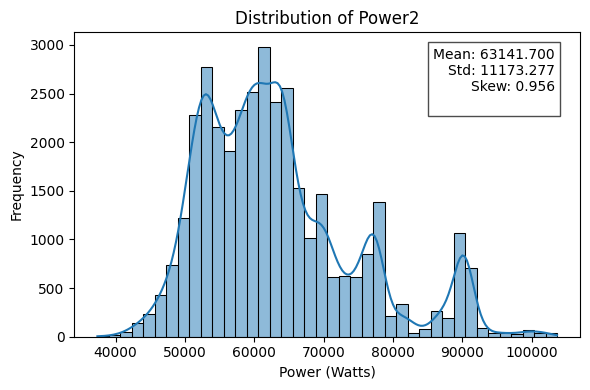

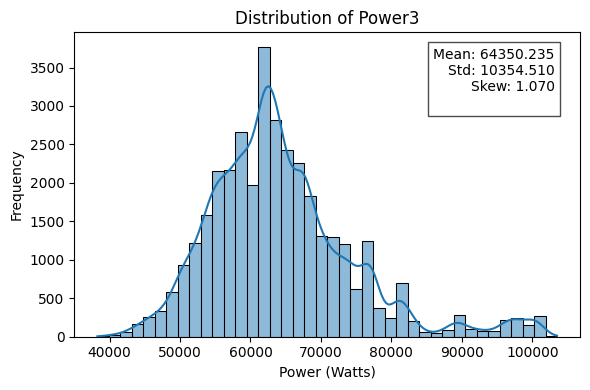

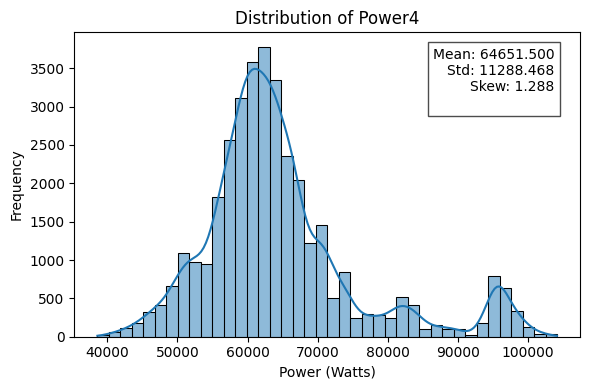

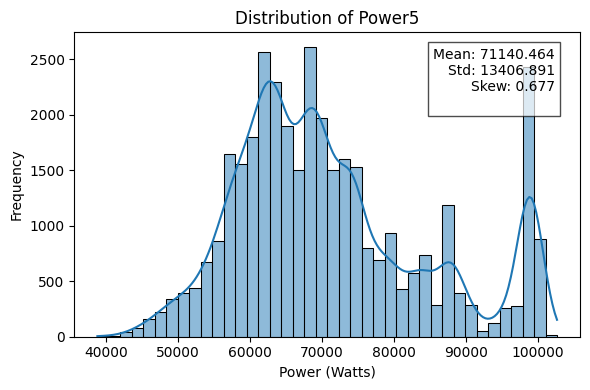

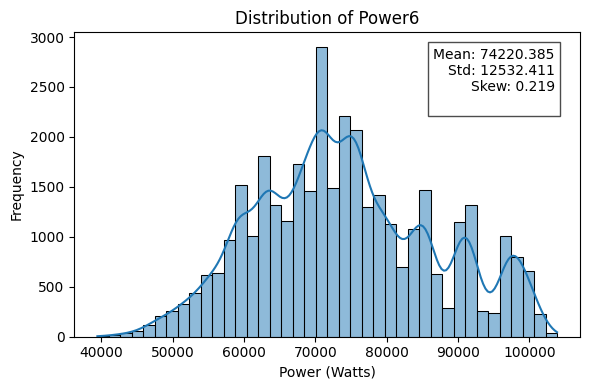

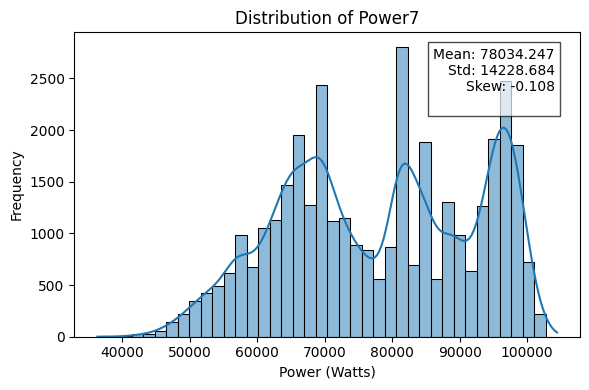

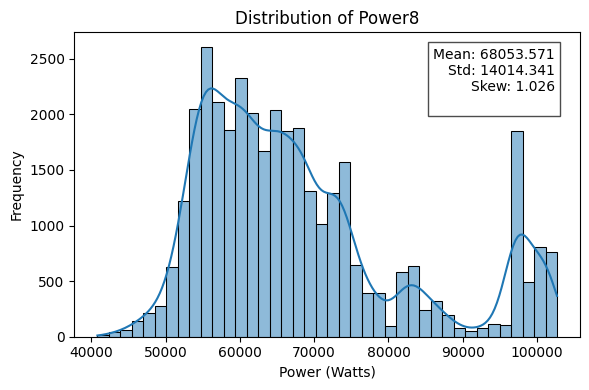

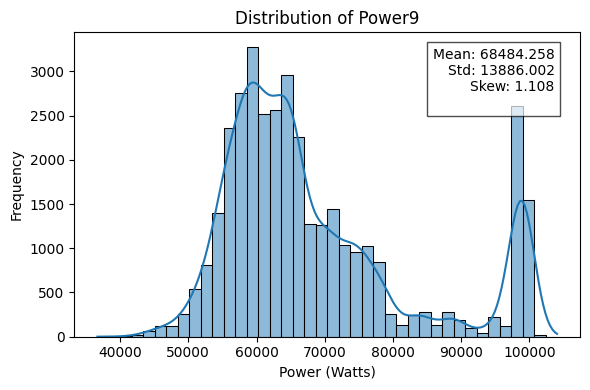

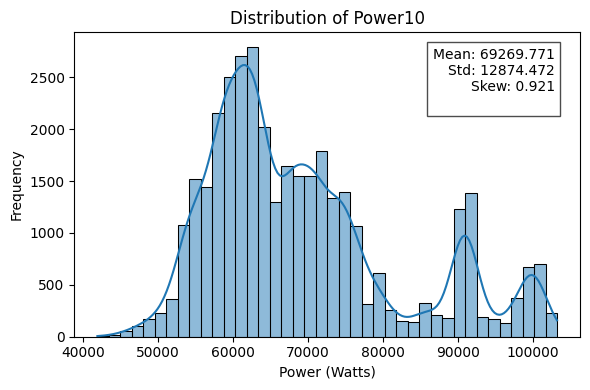

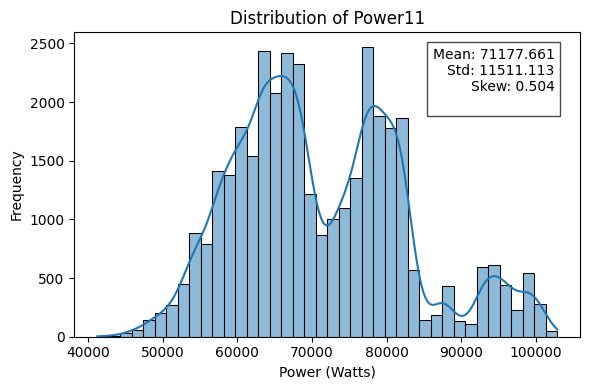

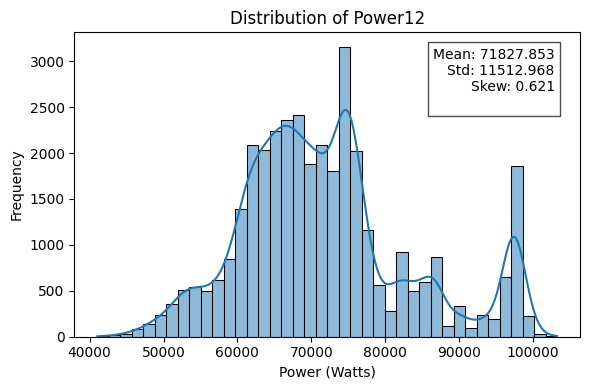

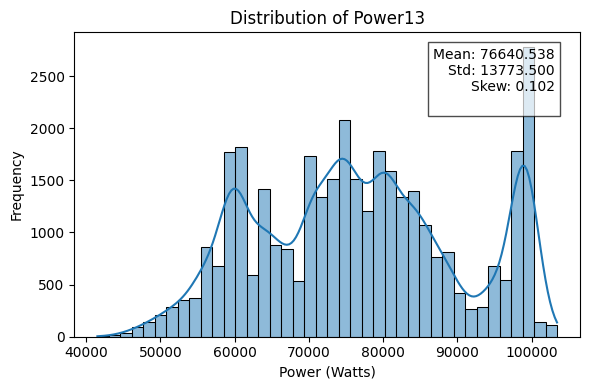

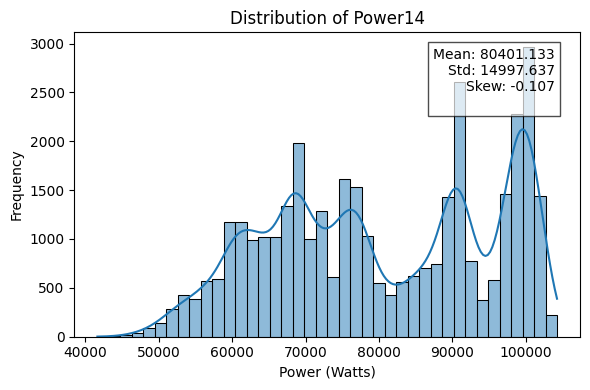

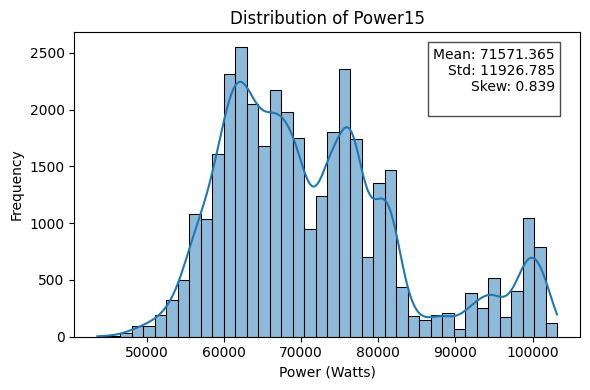

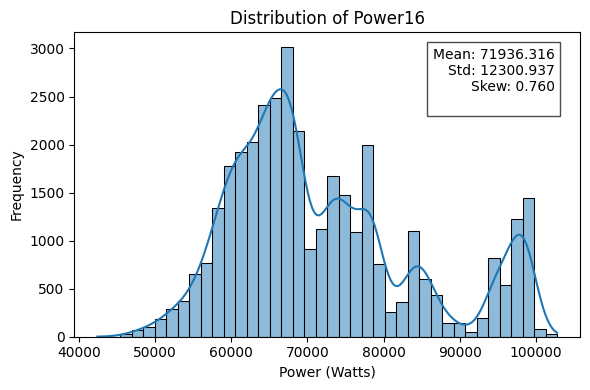

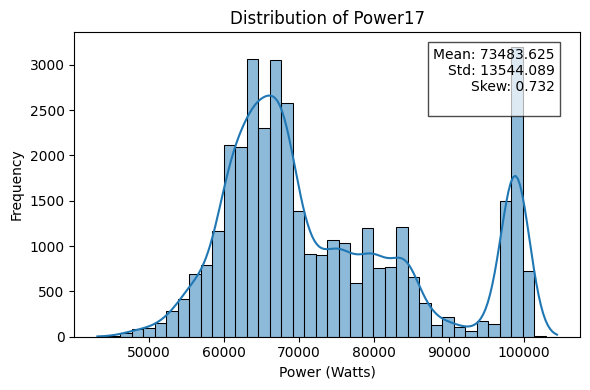

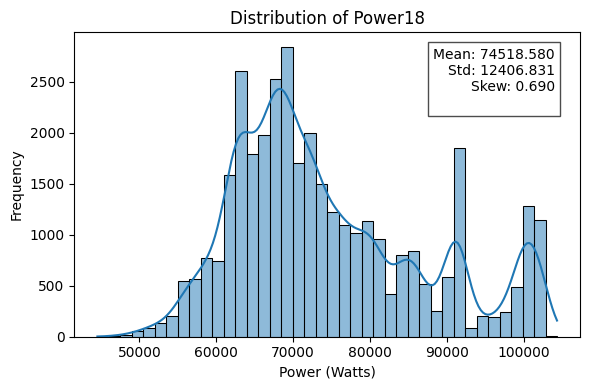

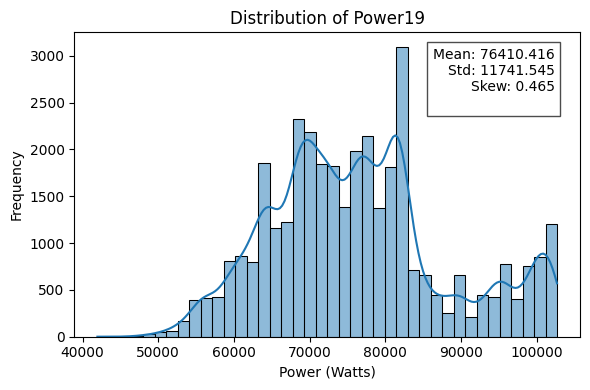

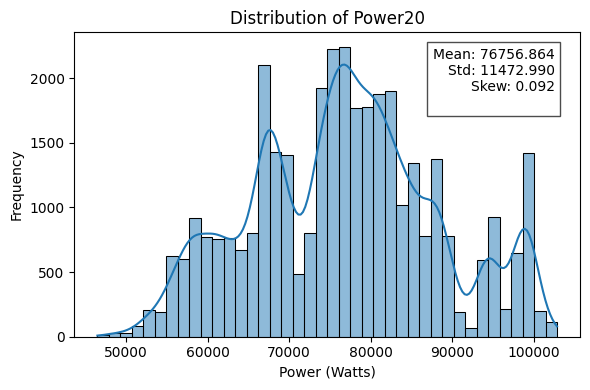

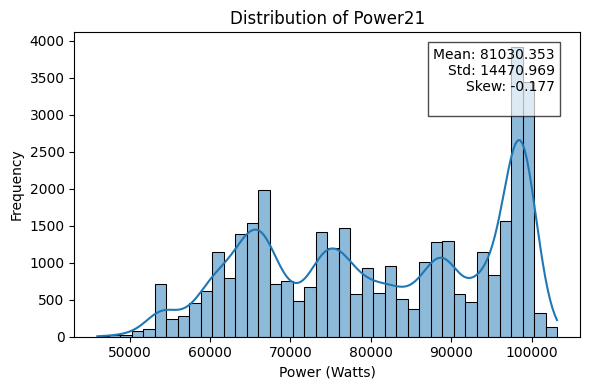

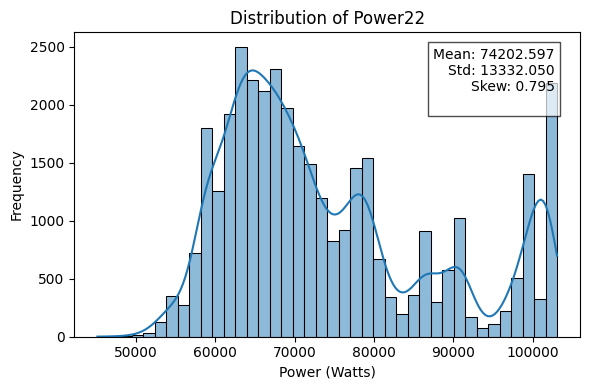

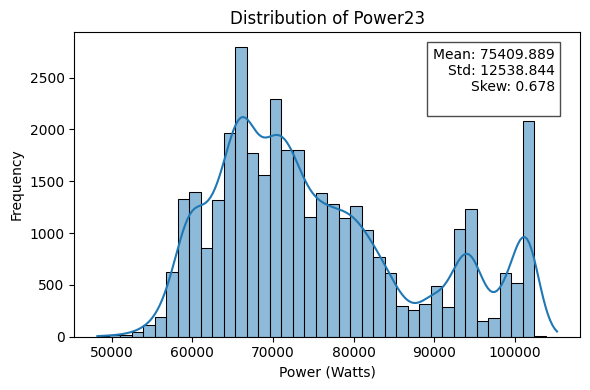

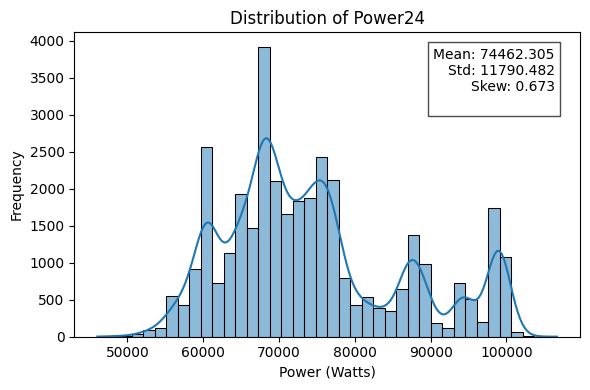

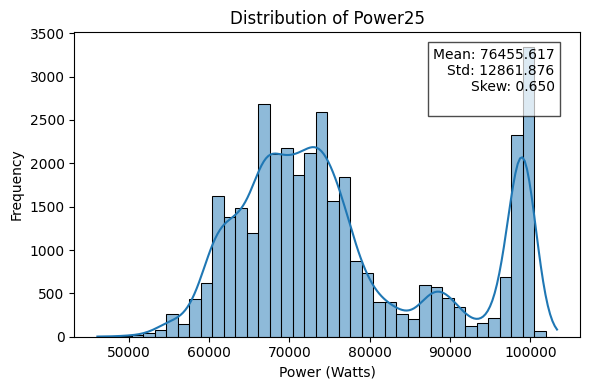

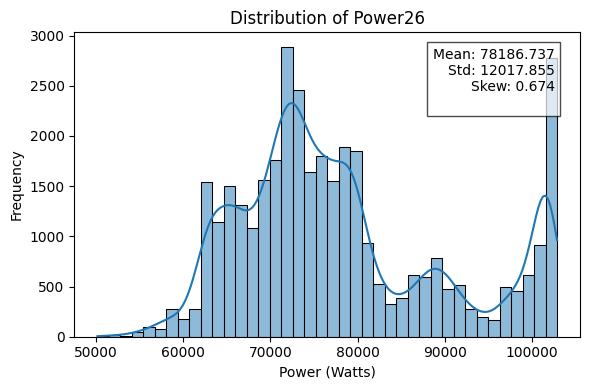

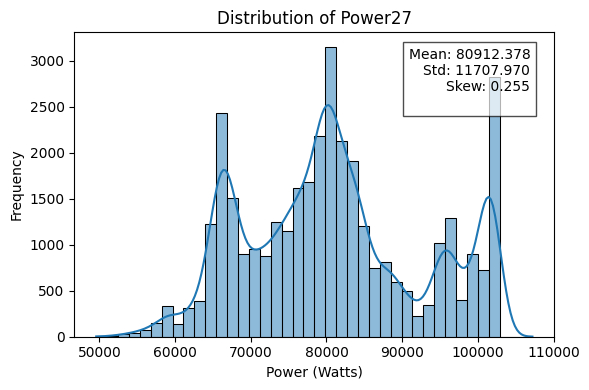

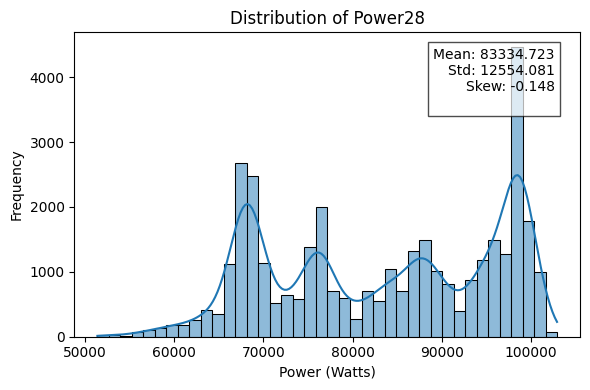

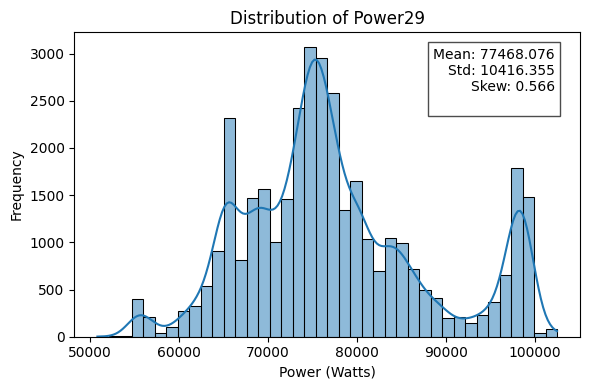

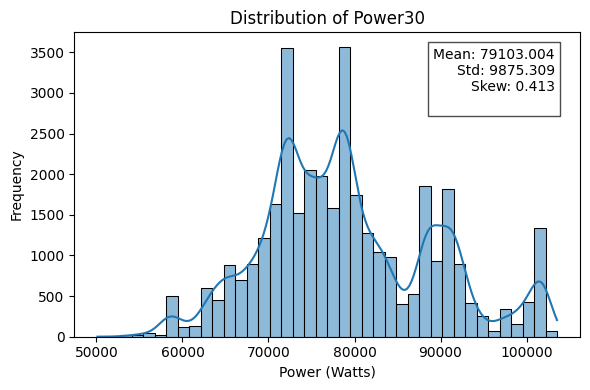

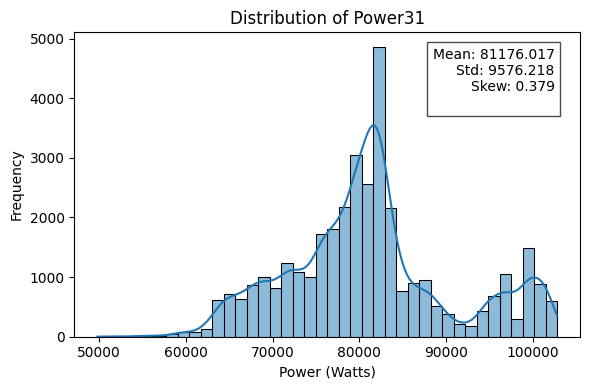

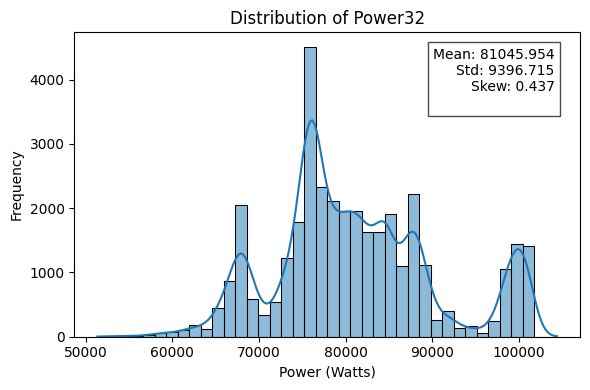

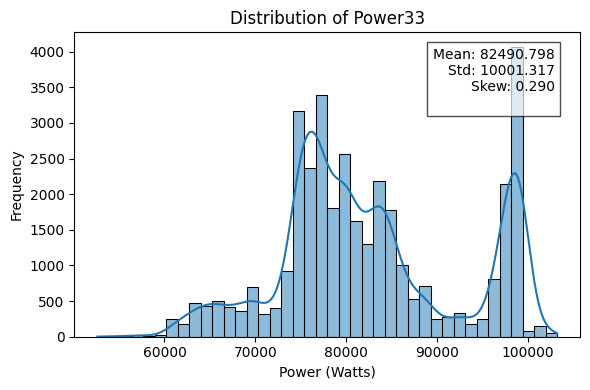

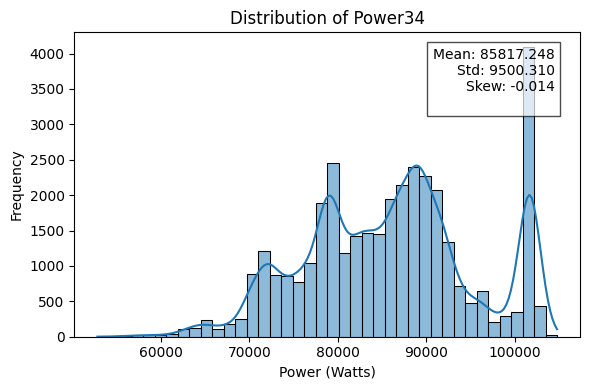

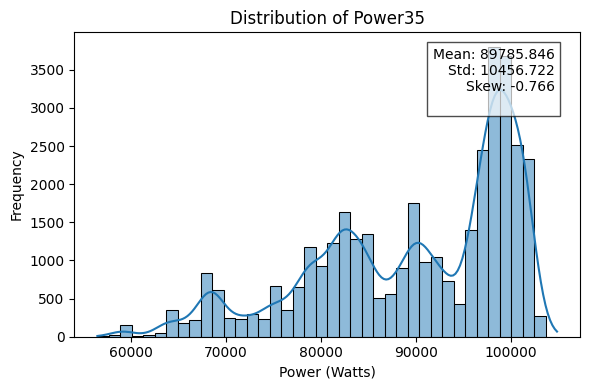

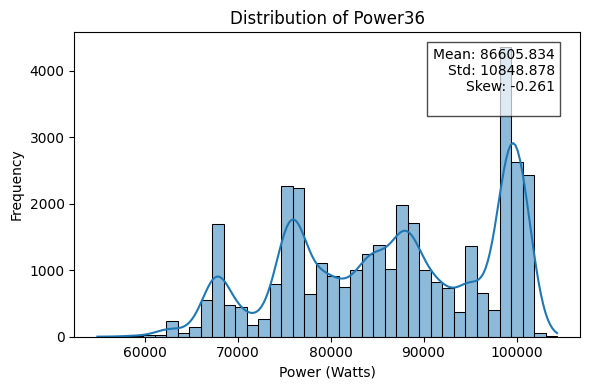

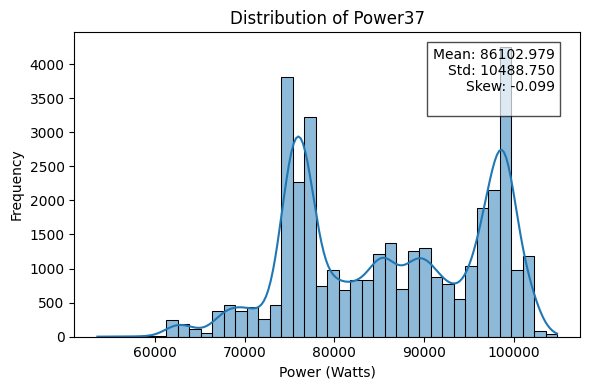

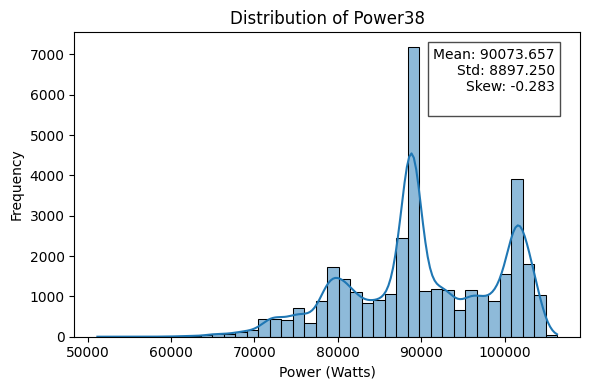

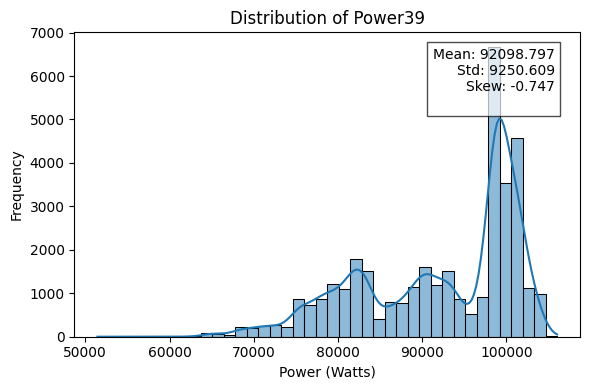

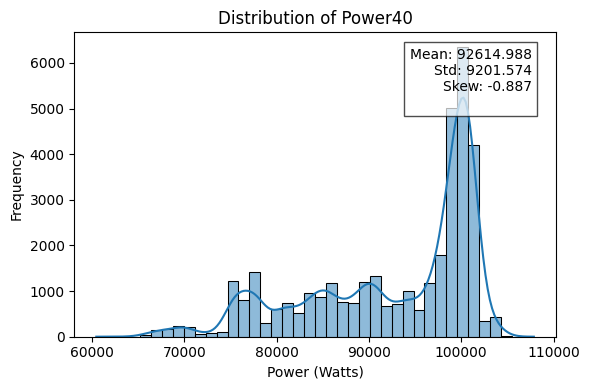

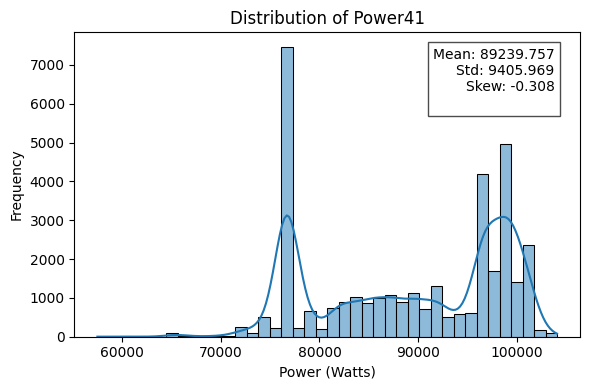

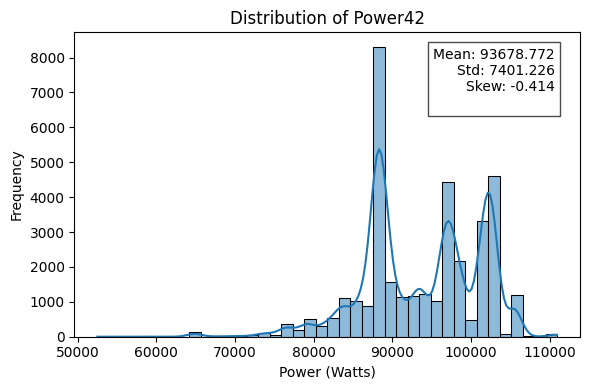

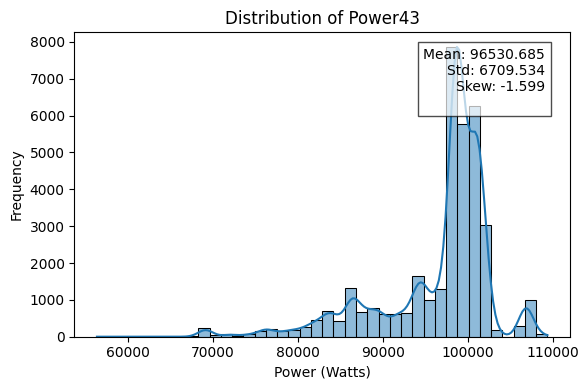

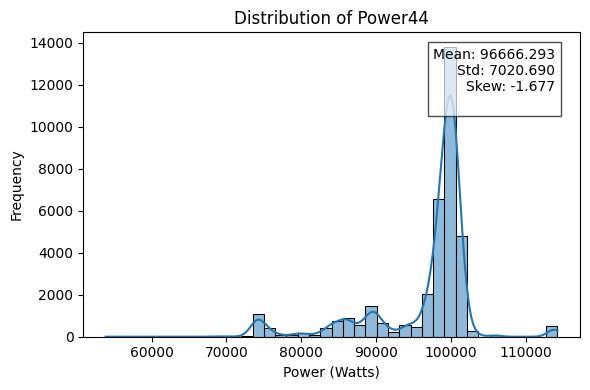

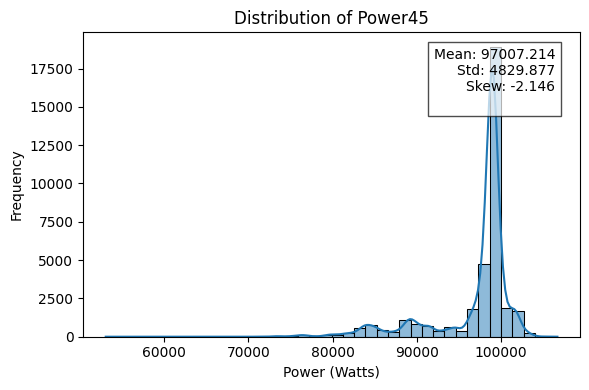

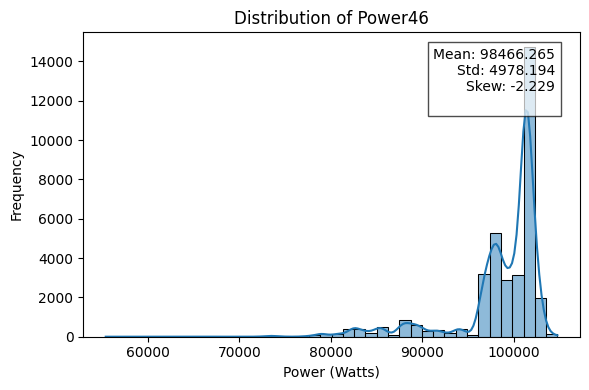

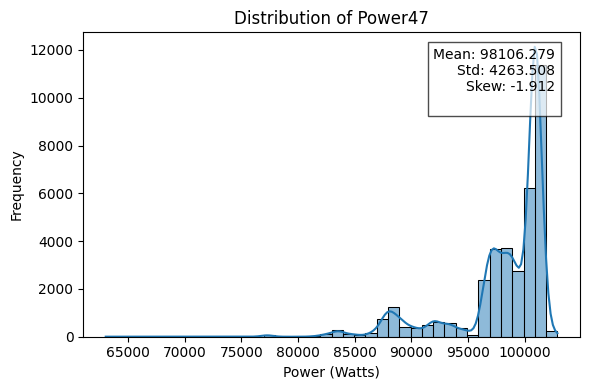

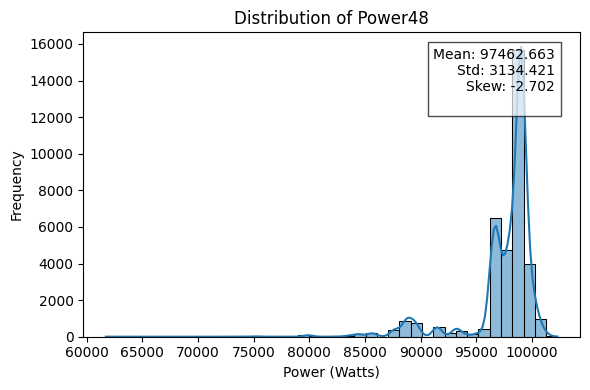

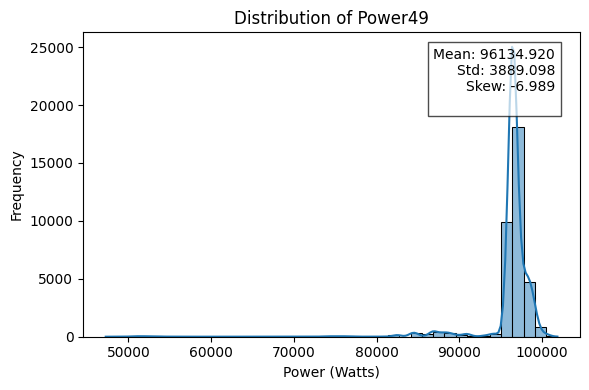

In [18]:
# Creating histograms for each PowerN feature.
# Trying to identify patterns in frequency, statistical metrics, and
# whether they follow a central distribution or will need to be standardized.
power_cols = [f"Power{i}" for i in range(1, 50)]

for col in power_cols:
    mean_val = df[col].mean()
    std_val = df[col].std()
    skew_val = df[col].skew()

    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=40)
    plt.title(f"Distribution of {col}")

    plt.text(
        0.95, 0.95,
        f"Mean: {mean_val:.3f}\n"
        f"Std: {std_val:.3f}\n"
        f"Skew: {skew_val:.3f}\n",
        transform=plt.gca().transAxes,
        ha='right', va='top',
        fontsize=10,
        bbox=dict(facecolor='white', alpha=0.7)
    )

    plt.xlabel("Power (Watts)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


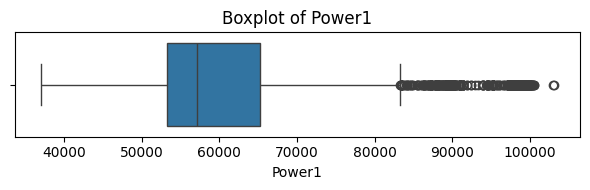

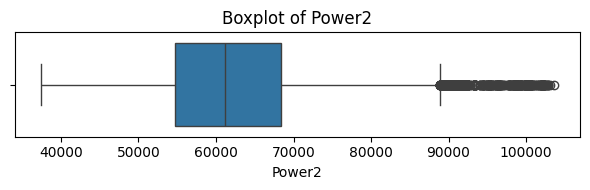

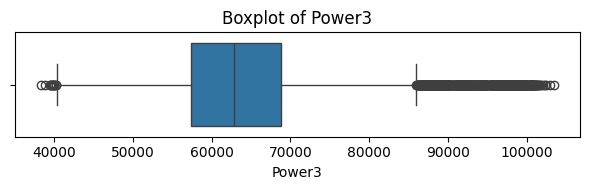

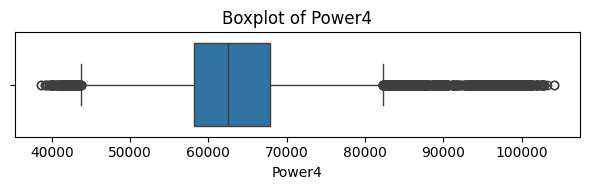

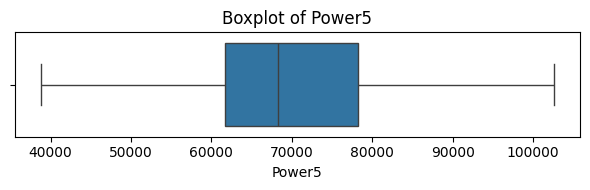

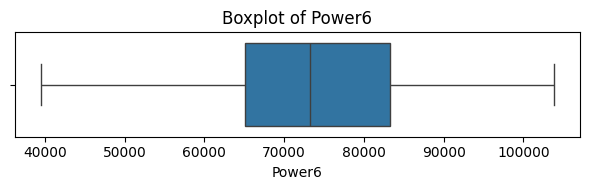

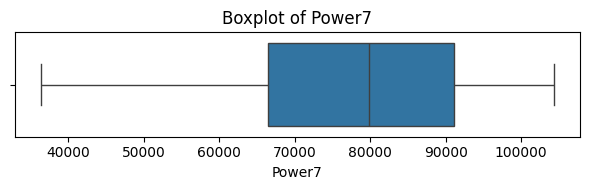

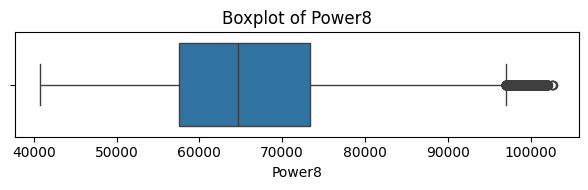

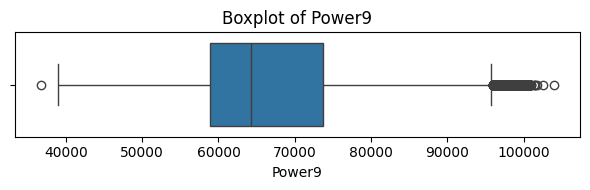

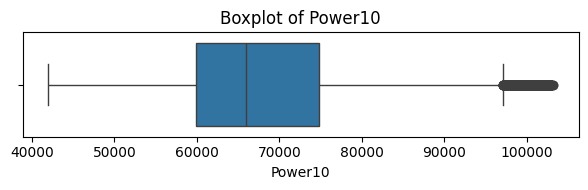

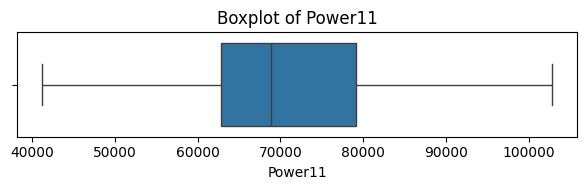

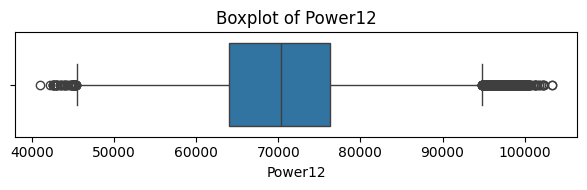

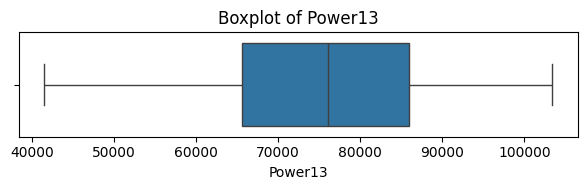

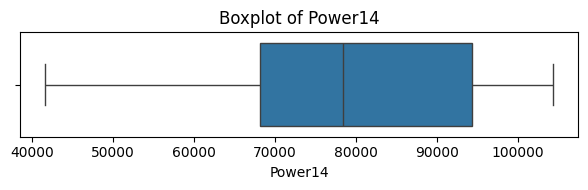

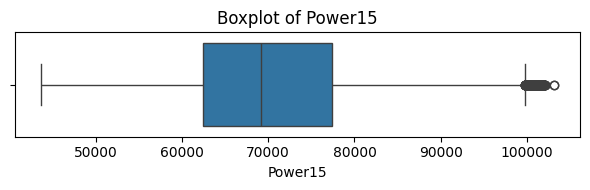

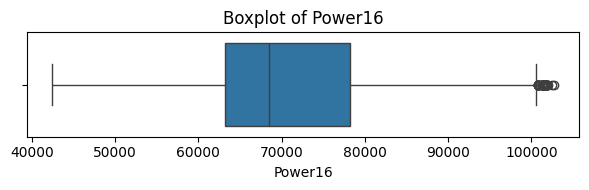

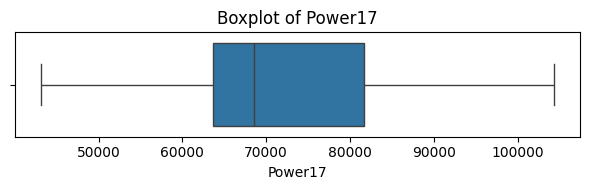

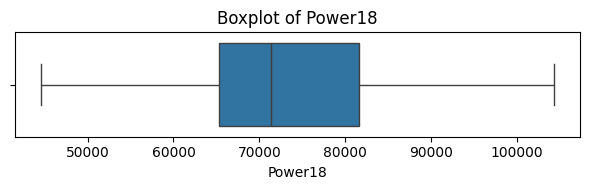

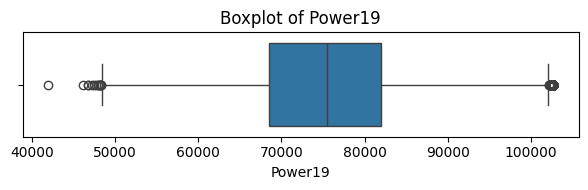

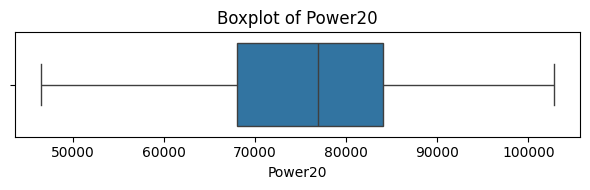

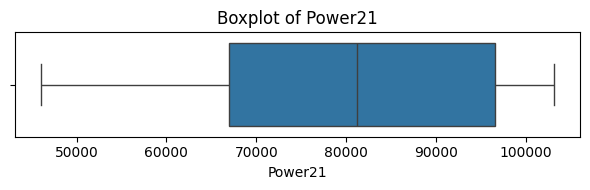

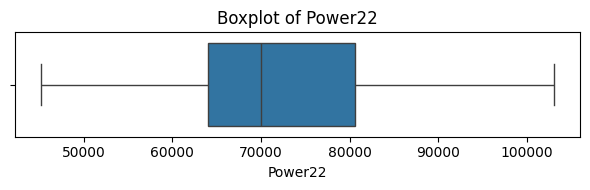

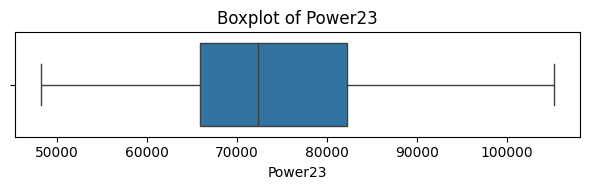

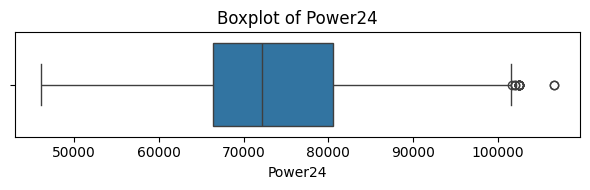

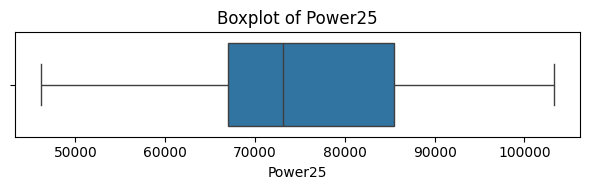

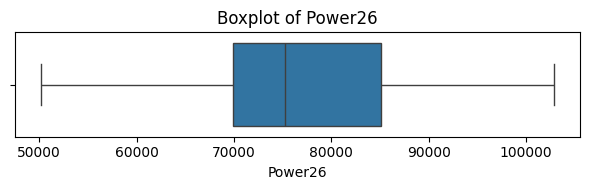

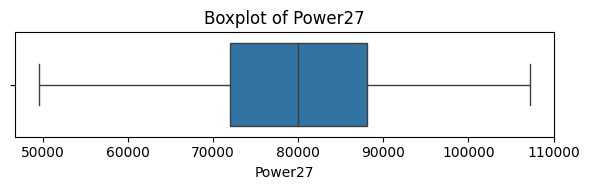

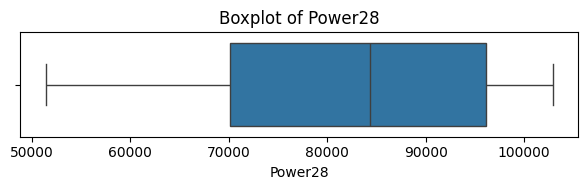

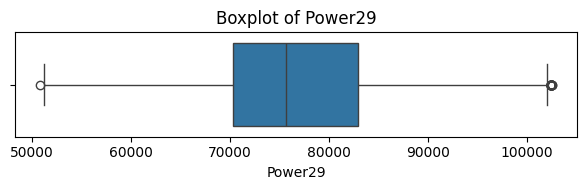

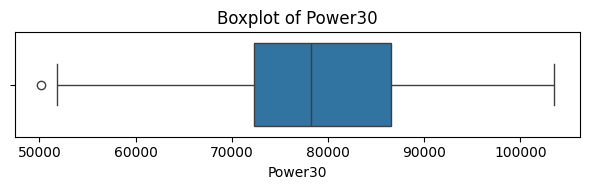

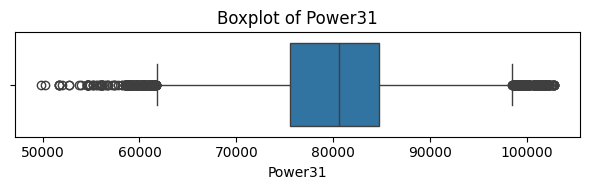

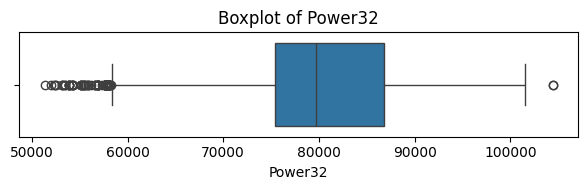

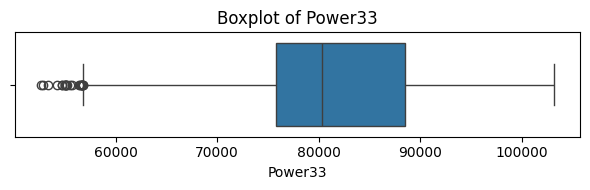

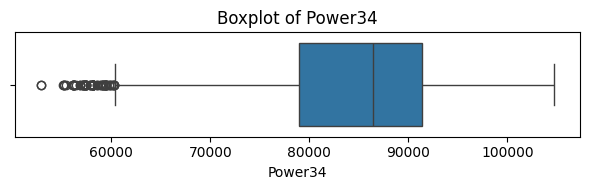

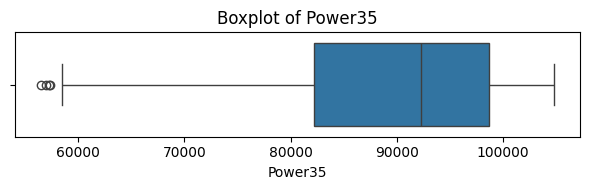

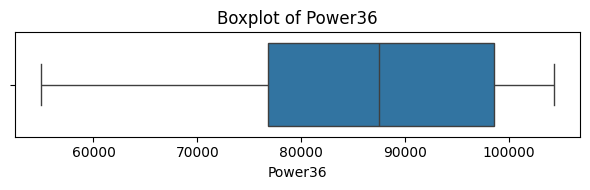

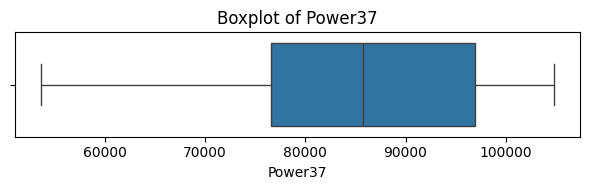

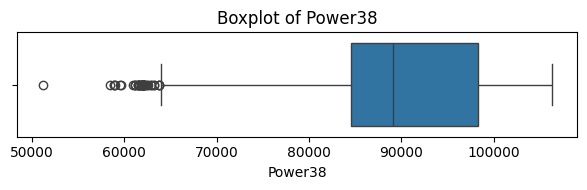

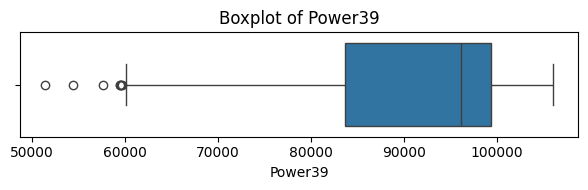

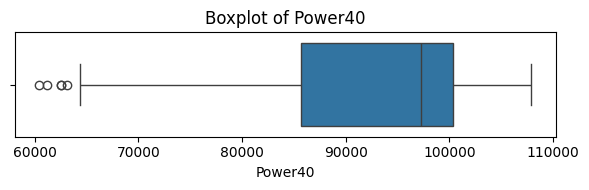

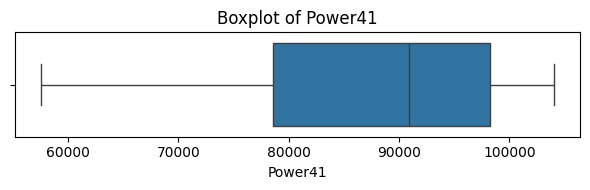

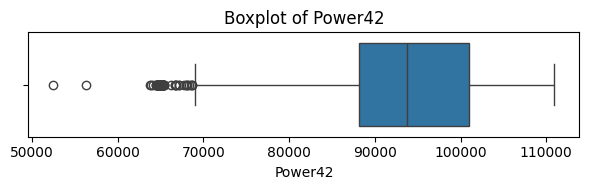

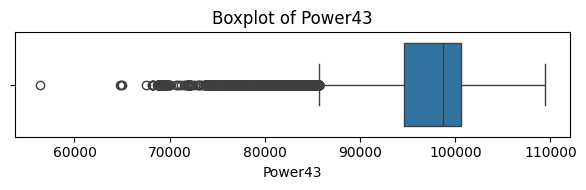

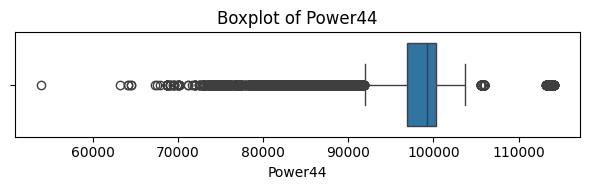

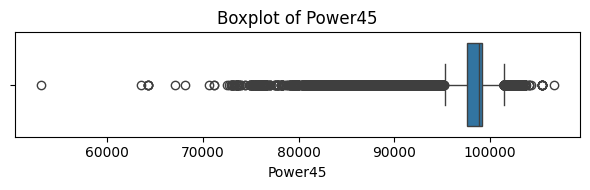

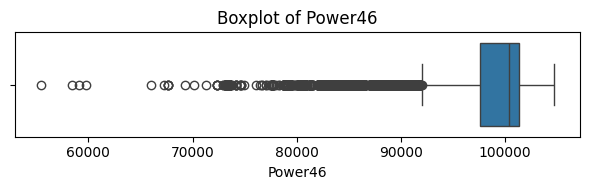

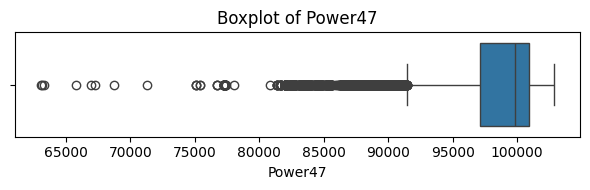

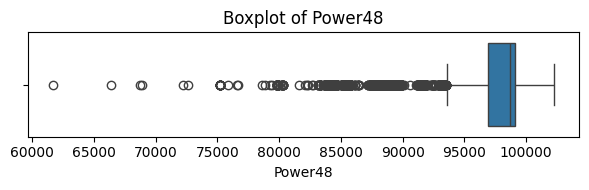

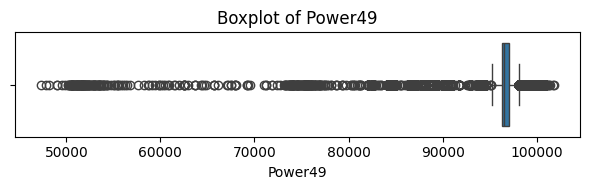

In [19]:
# Creating boxplot for PowerN features to identify median, IQR, and outliers
for col in power_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()


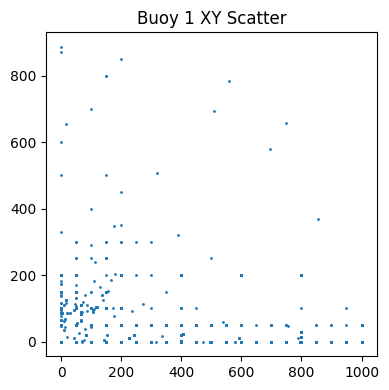

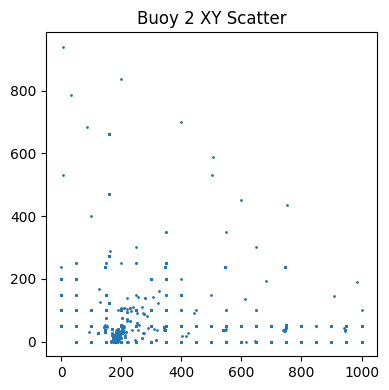

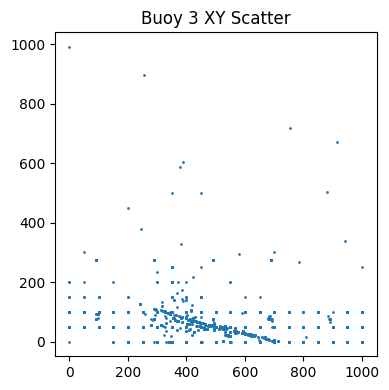

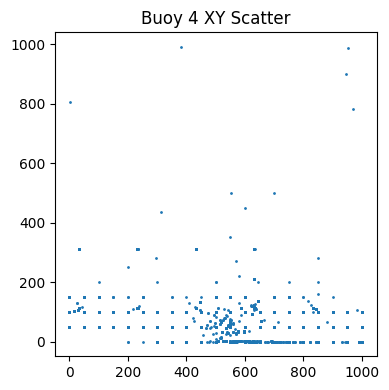

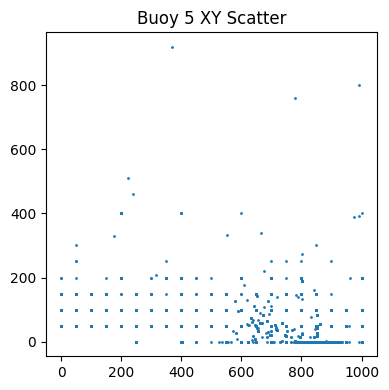

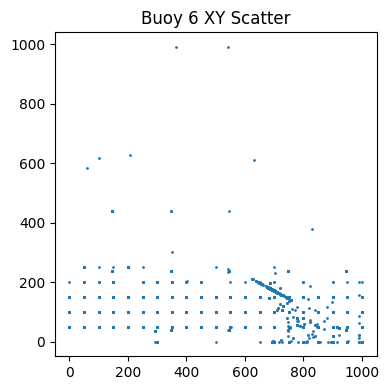

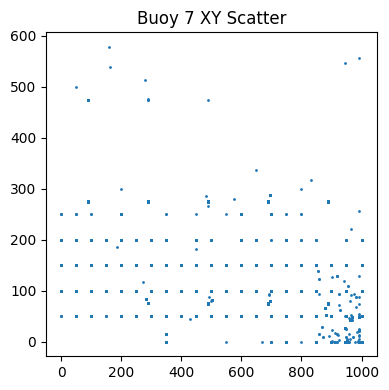

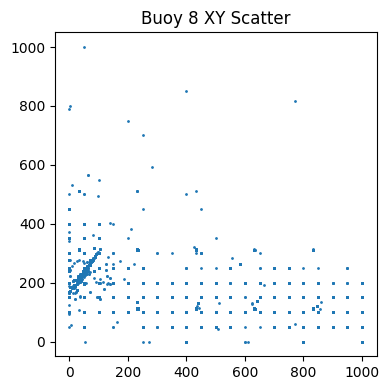

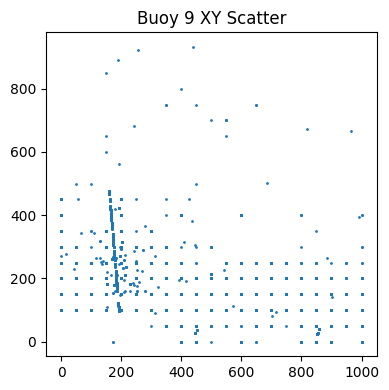

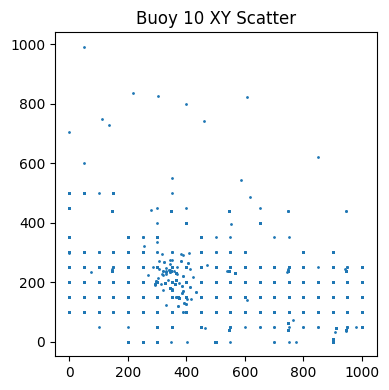

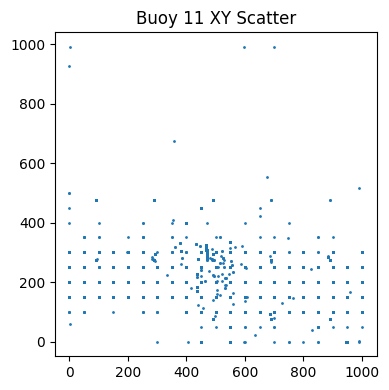

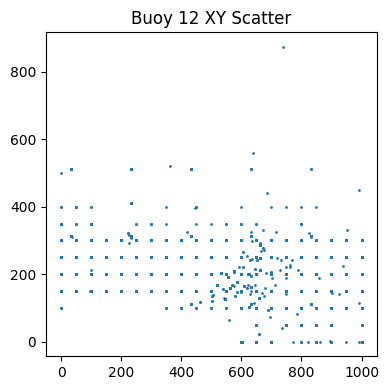

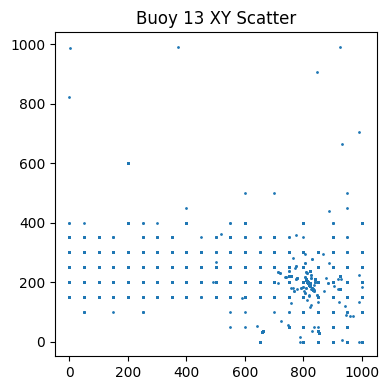

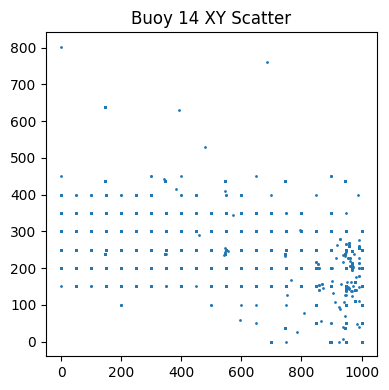

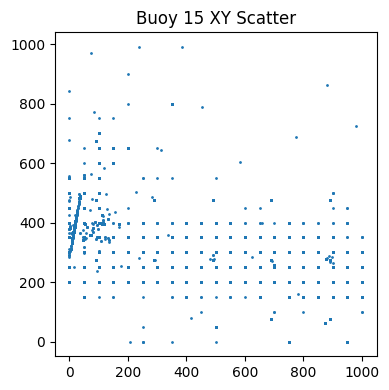

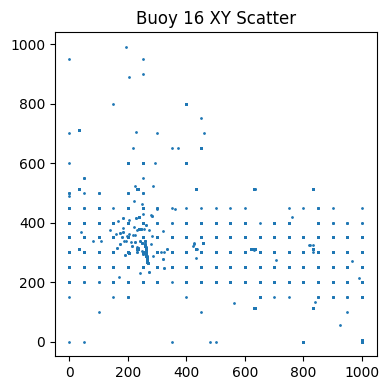

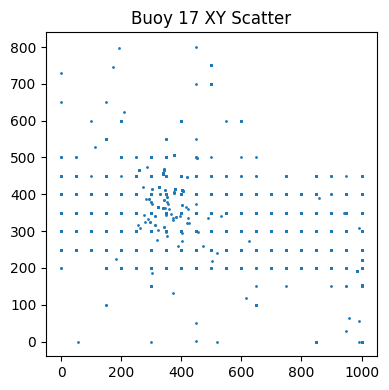

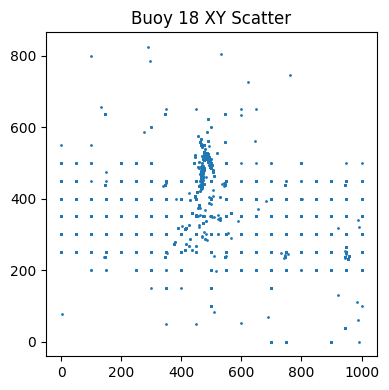

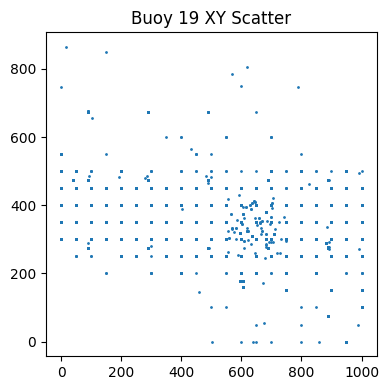

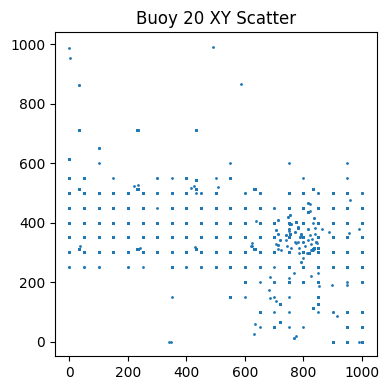

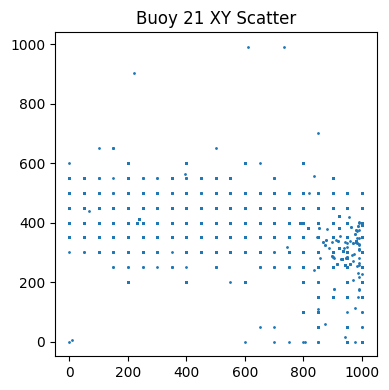

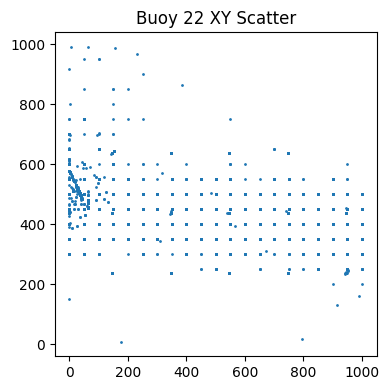

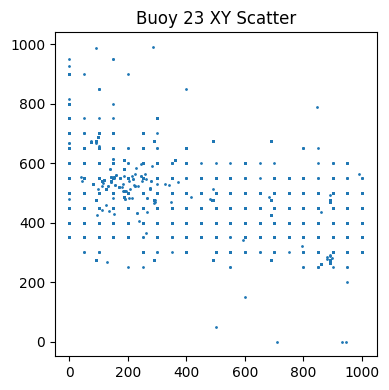

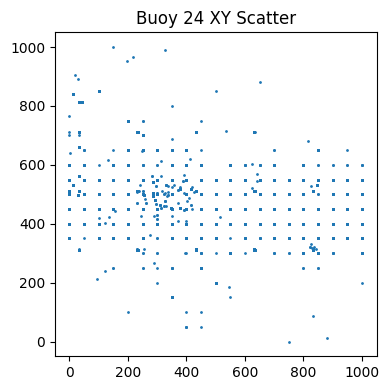

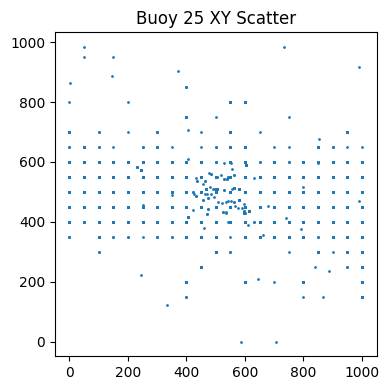

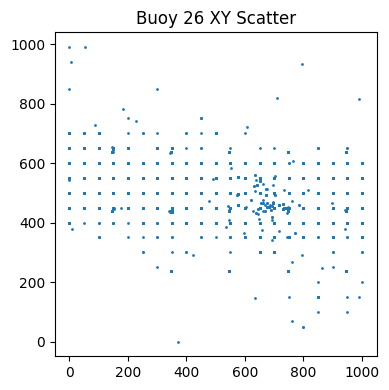

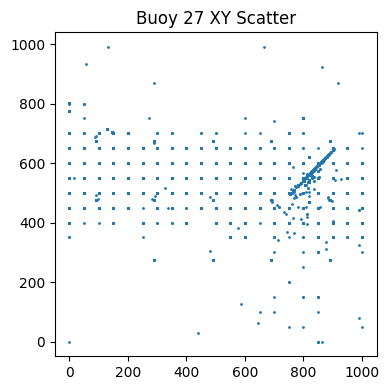

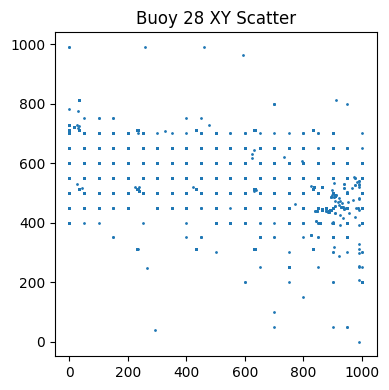

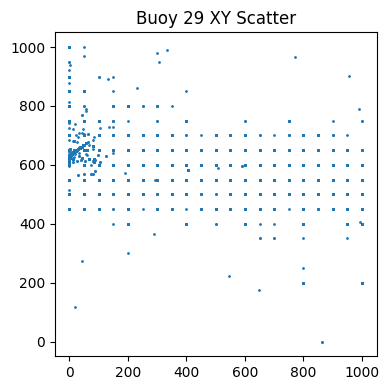

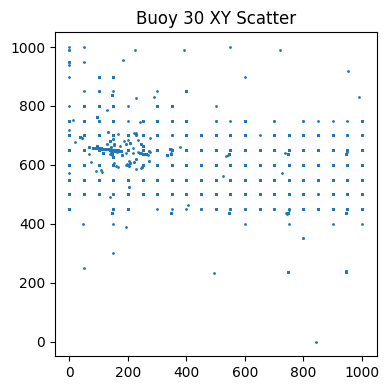

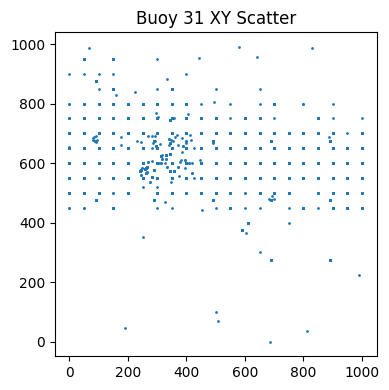

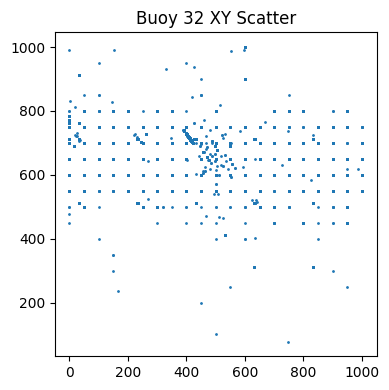

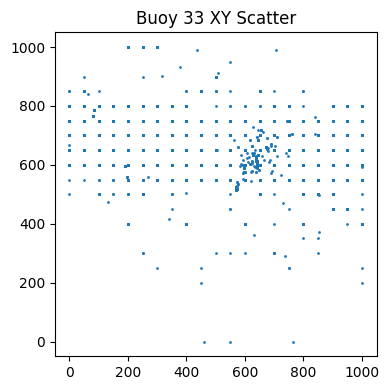

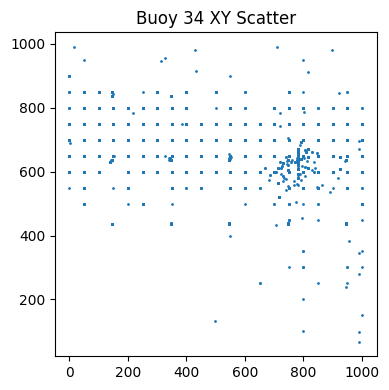

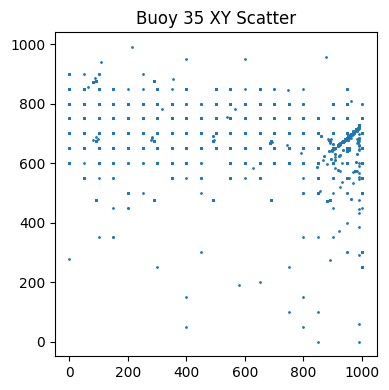

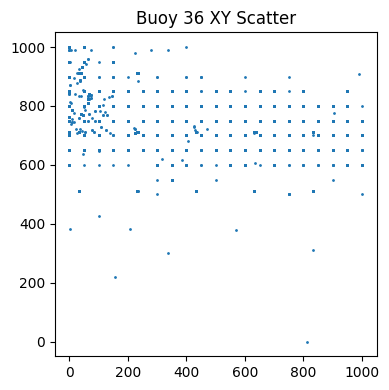

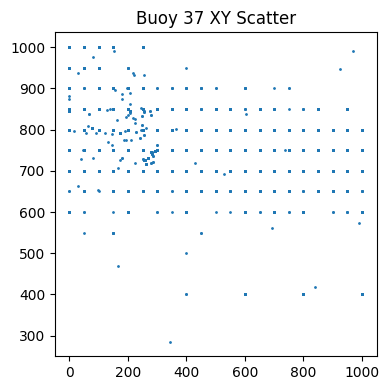

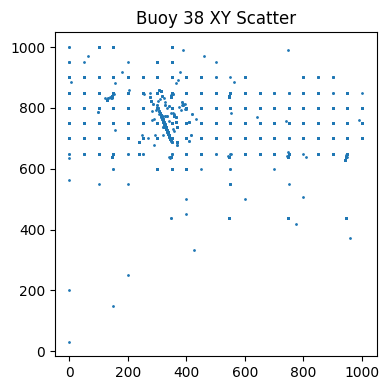

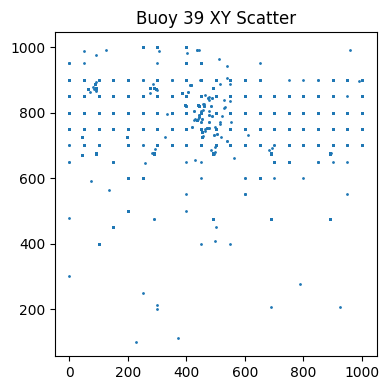

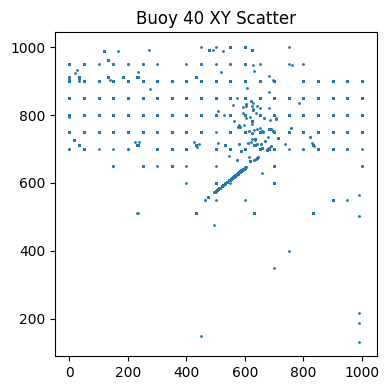

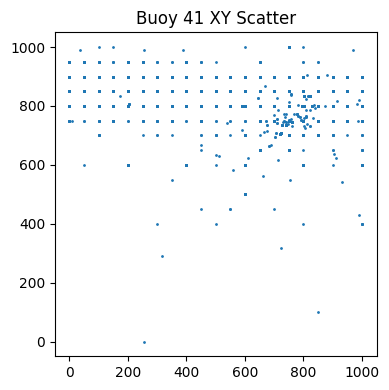

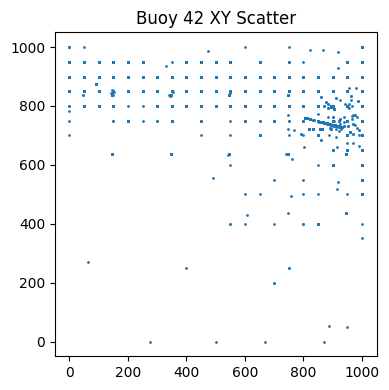

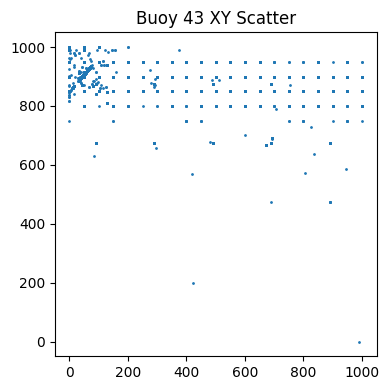

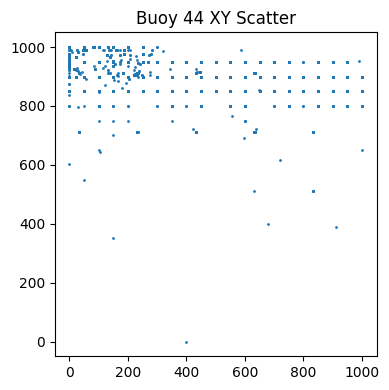

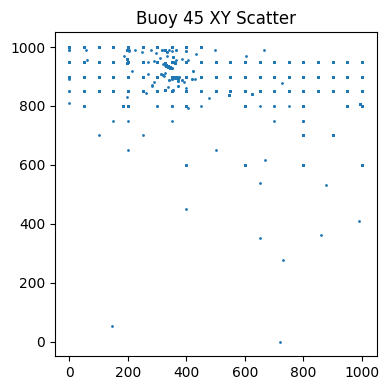

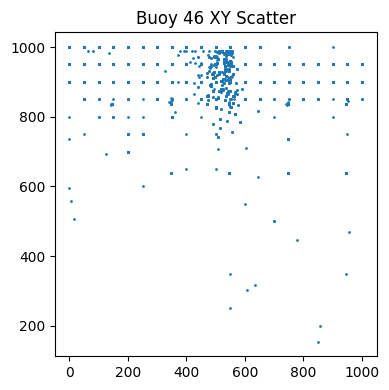

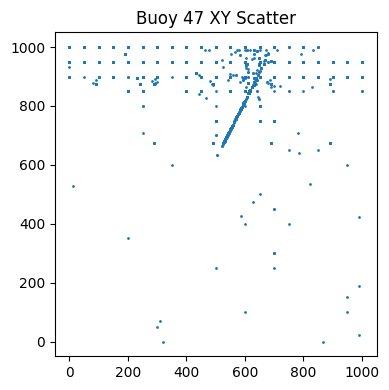

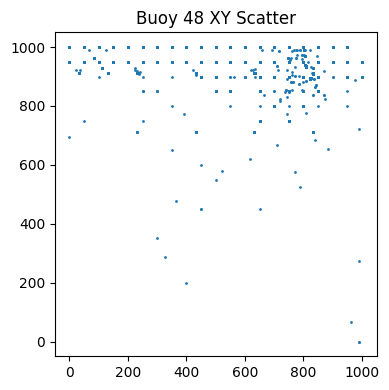

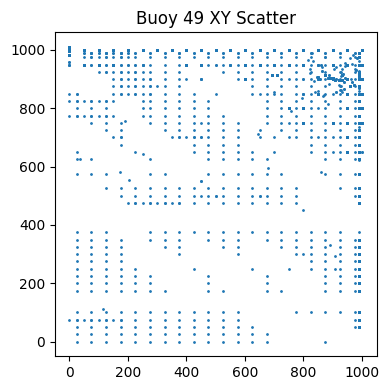

In [20]:
# X,Y scatter plot for each buoy to help identify clustering in buoy locations.
# Planned to use this data for initial coordinate -> power production prediction
# before the idea was scrapped.
for i in range(1, 50):
    plt.figure(figsize=(4,4))
    plt.scatter(df[f"X{i}"], df[f"Y{i}"], s=1)
    plt.title(f"Buoy {i} XY Scatter")
    plt.tight_layout()
    plt.show()


<Axes: >

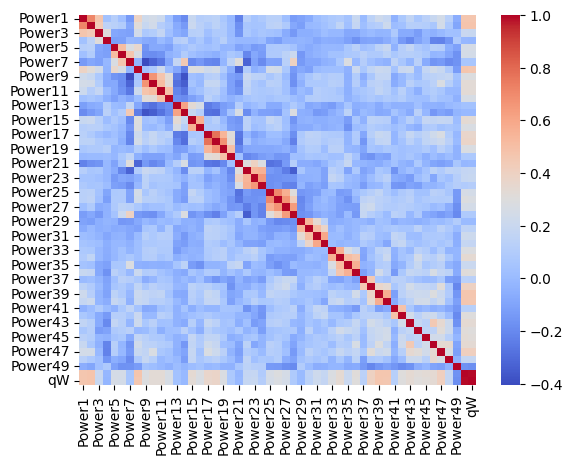

In [21]:
# General heatmap to identify correlation between PowerN features, total power
# features, and qW features (ratio of power production per buoy to overall
# power production of the entire farm)
sns.heatmap(df[power_cols + ['Total_Power', 'qW']].corr(), cmap='coolwarm')


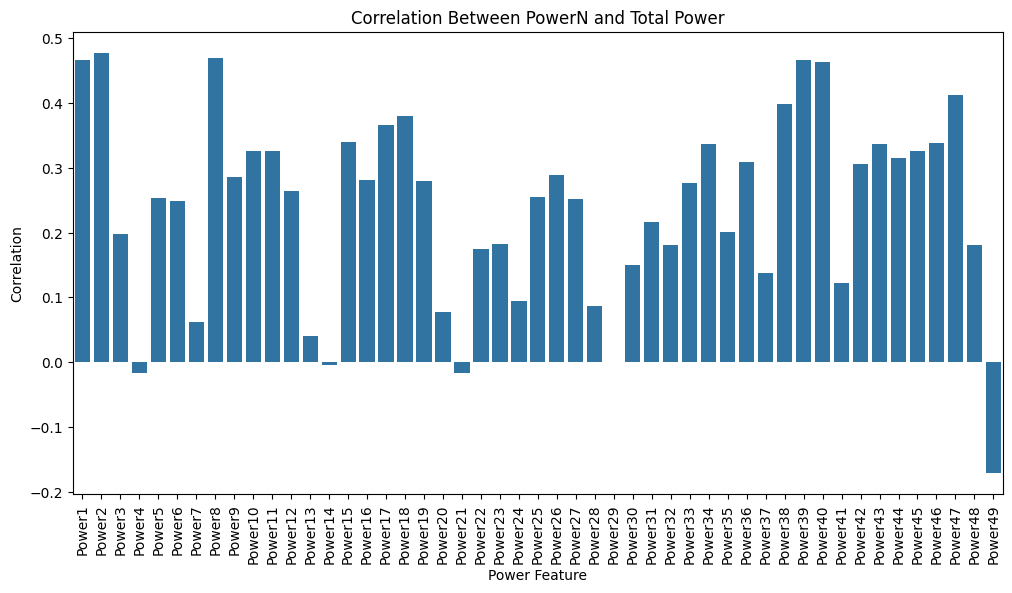

In [22]:
# Creating bar plot showing correlation between PowerN features and total power
# features. As expected, there is a strong correlation between the two
# since total power is directly affected by PowerN.
corr_power_total = df[power_cols + ['Total_Power']].corr()['Total_Power'].loc[power_cols]

plt.figure(figsize=(12,6))
sns.barplot(x=power_cols, y=corr_power_total.values)
plt.xticks(rotation=90)
plt.title("Correlation Between PowerN and Total Power")
plt.ylabel("Correlation")
plt.xlabel("Power Feature")
plt.show()
